#                                            **Assignment No. 2**
# *Supervised Learning: Predicting 1 Year Survival of Patients with Hepatocellular Carcinoma*

    The main goal of this assignment is to, by using supervised learning, try to predict if a patient will survive 1 year after being diagnosed with Hepatocellular Carcinoma (HCC)
    
   



# **Data Summary**

This hepatocellular carcinoma dataset consists of patient-data from 165 former patients of Hospital and University Centre of Coimbra (Portugal). The dataset contains 49 features selected according to the EASL-EORTC (European Association for the Study of the Liver - European Organization for Research and Treatment of Cancer) Clinical Practice Guidelines. The target variable, "Class", is the survival of each patient at 1 year and is represented as 'Dies' and 'Lives'

# **First Step -> Install dependencies**

In [ ]:
!pip install pandas numpy matplotlib seaborn

In [ ]:
!pip install -U ydata-profiling

In [ ]:
!pip install fancyimpute

In [ ]:
!pip install sklearn

# **Second Step -> Import Libraries**

In [5]:

import math
import random
import numpy as np
import pandas as pd
import seaborn as sns
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sb
from fancyimpute import KNN
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import precision_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, confusion_matrix, roc_curve, auc, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

%matplotlib inline

# **Data Exploration**

Let´s analyze our data!

In [6]:
hcc_data = pd.read_csv("hcc_dataset.csv")
hcc_data.head()

,Gender,Symptoms,Alcohol,HBsAg,HBeAg,HBcAb,HCVAb,Cirrhosis,Endemic,Smoking,...,ALP,TP,Creatinine,Nodules,Major_Dim,Dir_Bil,Iron,Sat,Ferritin,Class
0,Male,No,Yes,No,No,No,No,Yes,No,Yes,...,150,7.1,0.7,1,3.5,0.5,?,?,?,Lives
1,Female,?,No,No,No,No,Yes,Yes,?,?,...,?,?,?,1,1.8,?,?,?,?,Lives
2,Male,No,Yes,Yes,No,Yes,No,Yes,No,Yes,...,109,7,2.1,5,13,0.1,28,6,16,Lives
3,Male,Yes,Yes,No,No,No,No,Yes,No,Yes,...,174,8.1,1.11,2,15.7,0.2,?,?,?,Dies
4,Male,Yes,Yes,Yes,No,Yes,No,Yes,No,Yes,...,109,6.9,1.8,1,9,?,59,15,22,Lives


We see that we have categorical values in our data, so we will replace them with numerical values, doing a encoder method by hand, notice that we could use libraries to do this step, but we preferred doing this way.

In [7]:
# Read the CSV file into a DataFrame
df =pd.read_csv("hcc_dataset.csv")

# Replace "Lives" with "1" in all columns
df.replace("Lives", "1", inplace=True)

# Replace "Dies" with "0" in all columns
df.replace("Dies", "0", inplace=True)

# Replace "Yes" with "1" in all columns
df.replace("Yes", "1", inplace=True)

# Replace "No" with "0" in all columns
df.replace("No", "0", inplace=True)

# Replace "True" with "1" in all columns
df.replace("True", "1", inplace=True)

# Replace "False" with "0" in all columns
df.replace("False", "0", inplace=True)

# Replace "Male" with "1" in all columns
df.replace("Male", "1", inplace=True)

# Replace "Female" with "0" in all columns
df.replace("Female", "0", inplace=True)

# Replace "Active" with "0" in all columns
df.replace("Active", "0", inplace=True)

# Replace "Restricted" with "1" in all columns
df.replace("Restricted", "1", inplace=True)

# Replace "Ambulatory" with "2" in all columns
df.replace("Ambulatory", "2", inplace=True)

# Replace "Selfcare" with "3" in all columns
df.replace("Selfcare", "3", inplace=True)

# Replace "Disabled" with "4" in all columns
df.replace("Disabled", "4", inplace=True)

# Replace "None" with "1" in all columns
df.replace("None", "1", inplace=True)

# Replace "Grade I/II" with "2" in all columns
df.replace("Grade I/II", "2", inplace=True)

# Replace "Grade III/IV" with "3" in all columns
df.replace("Grade III/IV", "3", inplace=True)

# Replace "Mild" with "2" in all columns
df.replace("Mild", "2", inplace=True)

# Replace "Moderate/Severe" with "3" in all columns
df.replace("Moderate/Severe", "3", inplace=True)

# Write the modified DataFrame back to a CSV file
df.to_csv("modified_file.csv", index=False)

In [8]:
#Preview data
hcc_data = pd.read_csv("modified_file.csv")
hcc_data.head()

,Gender,Symptoms,Alcohol,HBsAg,HBeAg,HBcAb,HCVAb,Cirrhosis,Endemic,Smoking,...,ALP,TP,Creatinine,Nodules,Major_Dim,Dir_Bil,Iron,Sat,Ferritin,Class
0,1,0,1,0,0,0,0,1,0,1,...,150,7.1,0.7,1,3.5,0.5,?,?,?,1
1,0,?,0,0,0,0,1,1,?,?,...,?,?,?,1,1.8,?,?,?,?,1
2,1,0,1,1,0,1,0,1,0,1,...,109,7,2.1,5,13,0.1,28,6,16,1
3,1,1,1,0,0,0,0,1,0,1,...,174,8.1,1.11,2,15.7,0.2,?,?,?,0
4,1,1,1,1,0,1,0,1,0,1,...,109,6.9,1.8,1,9,?,59,15,22,1


Now that all our categarical values were replaced, we are going to create dummy variables for gender to prevent the algorithm to mistakenly interpret these values as having a specific order or magnitude.

In [9]:
# Create dummy variables for gender
dummy_gender = pd.get_dummies(hcc_data['Gender'], prefix='male', dummy_na=False)

# Map 'false' to 0 and 'true' to 1
dummy_gender = dummy_gender.astype(int)

# Concatenate the dummy variables with the original DataFrame
hcc_data = pd.concat([hcc_data, dummy_gender], axis=1)

# Drop the original 'Gender' column
hcc_data.drop(['Gender'], axis=1, inplace=True)


In [10]:
#Examine dataset shape
hcc_data.shape

(165, 51)

We can see that our dataset now has 51 columns! Which means our new 2 columns were created and our initial "Gender" column was removed.

Now its time to see how many missing values we have.

In [11]:
hcc_data_modified = hcc_data.replace('?', np.nan)

In [12]:
missing_data_summary = hcc_data_modified.isnull().sum()
print(missing_data_summary)

Symptoms           18
Alcohol             0
HBsAg              17
HBeAg              39
HBcAb              24
HCVAb               9
Cirrhosis           0
Endemic            39
Smoking            41
Diabetes            3
Obesity            10
Hemochro           23
AHT                 3
CRI                 2
HIV                14
NASH               22
Varices            52
Spleno             15
PHT                11
PVT                 3
Metastasis          4
Hallmark            2
Age                 0
Grams_day          48
Packs_year         53
PS                  0
Encephalopathy    143
Ascites           111
INR                 4
AFP                 8
Hemoglobin          3
MCV                 3
Leucocytes          3
Platelets           3
 Albumin            6
Total_Bil           5
ALT                 4
AST                 3
GGT                 3
ALP                 3
TP                 11
Creatinine          7
Nodules             2
Major_Dim          20
Dir_Bil            44
Iron      

Wow! We can see that we have many missing data, let's adress that problem later.

Now we want to see the percentage of people who Lives and Dies, for that we are going to create a pie graph!

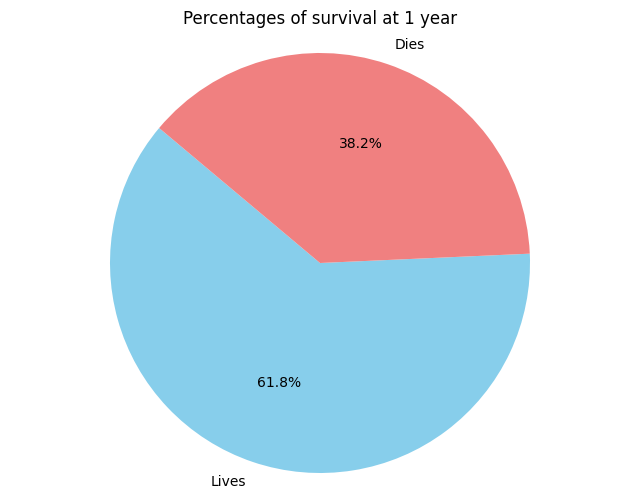

In [13]:
# Map 0 to 'Dies' and 1 to 'Lives'
hcc_data['Class'] = hcc_data['Class'].map({0: 'Dies', 1: 'Lives'})

# Calculate percentage of "Lives" and "Dies"
class_counts = hcc_data['Class'].value_counts(normalize=True) * 100

# Plotting
plt.figure(figsize=(8, 6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightcoral'], textprops={'color': 'black'})
plt.title('Percentages of survival at 1 year', color='black')  # Set title color to black
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

61.8% of the patients in our dataset lives 1 year after being diagnosed with HCC, still 38.2% is more than 1/3 of the patients, which means that it is a dangerous disease.

Let´s evaluate our data without rows with missing values.

[1 0]


''

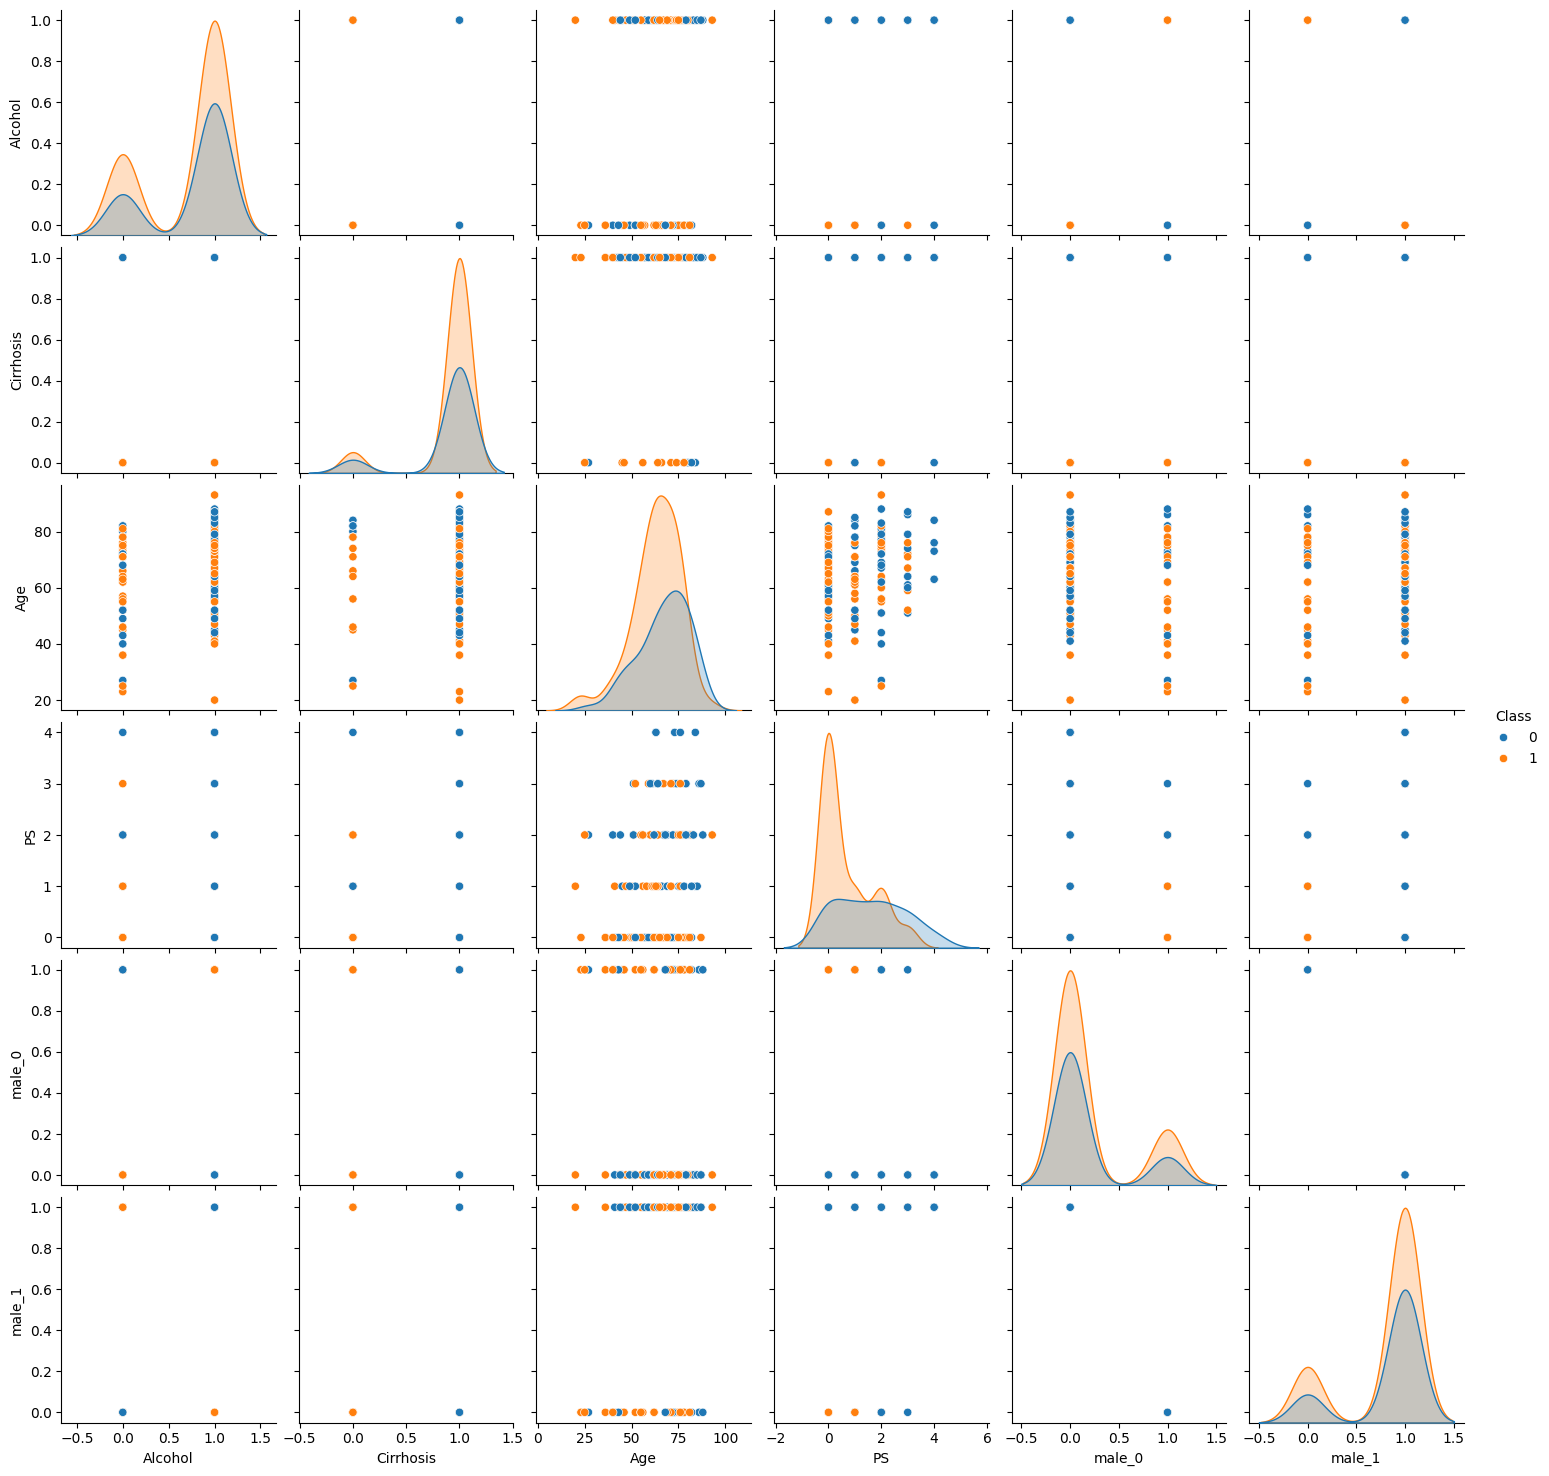

In [14]:
# Drop rows with missing values except in the 'Class' column
hcc_data_cleaned = hcc_data_modified.dropna(subset=['Class'])

# Check the unique values in the 'Class' column
print(hcc_data_cleaned['Class'].unique())

# Make sure 'Class' is categorical
hcc_data_cleaned['Class'] = hcc_data_cleaned['Class'].astype('category')

# Now, try plotting again
sb.pairplot(hcc_data_cleaned, hue='Class')
;

As we expected, the data that remains is very few, because almost all the features had missing values in it.

# **Data Preprocessing**

We had to drop the rows with missing values. Let's take a look at those now.

# Imputation 

For the ex-categorical values, we are going to fill the missing values with the most common value in each column. 

In [15]:
columns_to_impute = ['Symptoms','Alcohol','HBsAg','HBeAg','HBcAb','HCVAb','Cirrhosis','Endemic','Smoking','Diabetes','Obesity','Hemochro','AHT','CRI','HIV','NASH','Varices','Spleno','PHT','PVT','Metastasis','Hallmark','PS','Encephalopathy','Ascites']
df_filled_specific = hcc_data_modified.copy()
for column in columns_to_impute:
    most_common_value = df[column].mode()[0]
    df_filled_specific[column].fillna(most_common_value, inplace=True)
df_filled_specific.head()

C:\Users\pedro\AppData\Local\Temp\ipykernel_7280\3553547261.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filled_specific[column].fillna(most_common_value, inplace=True)


,Symptoms,Alcohol,HBsAg,HBeAg,HBcAb,HCVAb,Cirrhosis,Endemic,Smoking,Diabetes,...,Creatinine,Nodules,Major_Dim,Dir_Bil,Iron,Sat,Ferritin,Class,male_0,male_1
0,0,1,0,0,0,0,1,0,1,1,...,0.7,1,3.5,0.5,NaN,NaN,NaN,1,0,1
1,1,0,0,0,0,1,1,0,1,1,...,NaN,1,1.8,NaN,NaN,NaN,NaN,1,1,0
2,0,1,1,0,1,0,1,0,1,0,...,2.1,5,13,0.1,28,6,16,1,0,1
3,1,1,0,0,0,0,1,0,1,1,...,1.11,2,15.7,0.2,NaN,NaN,NaN,0,0,1
4,1,1,1,0,1,0,1,0,1,0,...,1.8,1,9,NaN,59,15,22,1,0,1


 # K-Nearest Neighbors

For the remaining missing values we are going to utilize KNN imputed data.

In [16]:
#Run KNN model using fancyimpute package
from fancyimpute import KNN

# Use 3 nearest rows which have a feature to fill in each row's missing features
# it returns a np.array which I store as a pandas dataframe
hcc_filled = pd.DataFrame(KNN(3).fit_transform(df_filled_specific))


Imputing row 1/165 with 3 missing, elapsed time: 0.009
Imputing row 101/165 with 2 missing, elapsed time: 0.013


In [17]:
##the column categories were removed when imputed into model, reinsert column headings
hcc_filled.columns = df_filled_specific.columns
hcc_filled.index = df_filled_specific.index
hcc_filled.head()

,Symptoms,Alcohol,HBsAg,HBeAg,HBcAb,HCVAb,Cirrhosis,Endemic,Smoking,Diabetes,...,Creatinine,Nodules,Major_Dim,Dir_Bil,Iron,Sat,Ferritin,Class,male_0,male_1
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,0.700000,1.0,3.5,0.500000,172.333450,78.115393,680.443002,1.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,...,1.373731,1.0,1.8,0.654251,187.475510,68.336908,530.646573,1.0,1.0,0.0
2,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,2.100000,5.0,13.0,0.100000,28.000000,6.000000,16.000000,1.0,0.0,1.0
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,...,1.110000,2.0,15.7,0.200000,71.664253,26.132320,399.669156,0.0,0.0,1.0
4,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.800000,1.0,9.0,0.358185,59.000000,15.000000,22.000000,1.0,0.0,1.0


Now that we don't have missing values anymore it's time to start the work!

## Panda Profile Report


Creating a Profile Report will help us see every correlation and detail about each feature.

In [ ]:
profile = ProfileReport(hcc_filled, title='Pandas Profiling Report', explorative=True)
profile.to_file("hcc_filled.html")

# Correlation Matrix

Let´s see the correlation among the dataset features.

In [19]:
# Basic correlogram demonstrates minimal correlation among the dataset features
corr = hcc_filled.corr()
corr.style.background_gradient(cmap='coolwarm')

,Symptoms,Alcohol,HBsAg,HBeAg,HBcAb,HCVAb,Cirrhosis,Endemic,Smoking,Diabetes,Obesity,Hemochro,AHT,CRI,HIV,NASH,Varices,Spleno,PHT,PVT,Metastasis,Hallmark,Age,Grams_day,Packs_year,PS,Encephalopathy,Ascites,INR,AFP,Hemoglobin,MCV,Leucocytes,Platelets,Albumin,Total_Bil,ALT,AST,GGT,ALP,TP,Creatinine,Nodules,Major_Dim,Dir_Bil,Iron,Sat,Ferritin,Class,male_0,male_1
Symptoms,1.000000,-0.024013,0.093837,0.053716,0.098836,-0.002528,-0.093837,0.065935,0.037806,-0.109977,-0.102434,0.016001,0.134090,0.056640,-0.197822,0.034426,-0.121316,-0.058287,0.025437,0.111991,0.237696,0.092111,-0.008193,0.157040,-0.077058,0.242010,0.108429,0.157450,0.005664,0.047345,-0.145558,-0.149263,0.110584,0.147076,-0.141195,0.054983,0.065727,0.074322,0.107664,0.207904,0.060221,-0.029205,0.044068,0.180975,0.079504,-0.137153,-0.066507,0.097661,-0.220040,-0.056503,0.056503
Alcohol,-0.024013,1.000000,-0.085396,0.046359,-0.068765,-0.141297,0.458652,-0.080658,0.288961,0.017318,0.093579,0.124961,-0.017982,-0.033330,-0.022546,-0.058826,0.141536,0.078911,0.422528,0.146480,0.012764,0.191640,0.162934,0.417337,-0.059159,0.161536,0.003808,0.030598,0.205705,0.071302,-0.109422,0.191025,-0.070935,-0.127117,-0.137746,0.022694,0.000828,0.048453,0.095901,-0.118568,-0.092128,-0.016819,0.025913,-0.181318,-0.032471,0.031121,0.035700,0.055395,-0.040302,-0.442103,0.442103
HBsAg,0.093837,-0.085396,1.000000,0.238293,0.404490,-0.015037,0.107383,0.345942,0.038828,-0.191627,-0.121702,-0.068974,0.011913,0.003803,0.108696,-0.073971,0.058664,0.058529,0.058664,0.074834,0.174012,-0.086300,0.021509,-0.004468,0.217177,0.134037,0.347841,0.082418,-0.013234,-0.021988,0.015787,0.094542,0.035099,-0.088450,0.073934,0.137654,0.078387,0.085205,-0.013006,0.022668,-0.050698,0.088194,0.120276,0.123100,0.111403,-0.049659,-0.035795,-0.056593,0.046755,-0.160737,0.160737
HBeAg,0.053716,0.046359,0.238293,1.000000,0.142754,-0.039782,0.025589,-0.019834,0.059803,-0.055970,-0.029001,-0.016436,-0.058257,-0.029001,-0.010626,-0.017627,0.047088,0.063758,0.047088,-0.041251,-0.041251,-0.115111,-0.009943,0.075929,-0.025461,0.197667,0.495406,-0.027325,0.165944,0.002196,-0.032318,0.153229,-0.040138,-0.031731,-0.018754,0.230549,0.091740,0.074148,-0.065426,-0.032316,-0.006435,0.176318,-0.075006,-0.071986,0.157088,0.033207,0.098251,0.357677,-0.099359,-0.038303,0.038303
HBcAb,0.098836,-0.068765,0.404490,0.142754,1.000000,0.219573,0.130604,0.102376,-0.028374,-0.270474,0.017375,-0.043717,-0.077724,-0.026731,0.141040,0.010561,-0.028211,-0.023507,0.069443,-0.044992,0.059567,-0.031736,-0.107594,-0.033835,-0.014874,-0.057324,0.100968,0.039458,-0.078113,-0.050632,0.117265,0.077748,-0.054595,-0.153819,0.079759,-0.100755,0.237222,0.169357,-0.009642,-0.111855,0.140724,-0.051489,-0.026541,-0.107717,-0.115816,0.126354,0.164172,0.072944,0.074342,-0.049867,0.049867
HCVAb,-0.002528,-0.141297,-0.015037,-0.039782,0.219573,1.000000,0.065673,0.121789,0.048724,-0.017069,-0.097385,0.041451,-0.098715,-0.051475,0.267116,-0.045239,-0.031625,0.048937,0.002259,-0.124010,0.057388,-0.009187,-0.223973,-0.074672,-0.060072,-0.147788,0.017123,0.013982,-0.075914,-0.028548,0.113927,0.056863,-0.005823,0.077911,0.014618,0.189945,0.321741,0.295298,0.042369,0.046273,0.044834,0.185098,0.038319,-0.054879,0.192781,0.088261,0.103692,0.128791,-0.093086,0.053286,-0.053286
Cirrhosis,-0.093837,0.458652,0.107383,0.025589,0.130604,0.065673,1.000000,-0.088436,0.215738,0.018612,0.121702,0.068974,-0.140109,-0.129308,0.044593,-0.021382,0.265533,0.234115,0.311847,0.123522,-0.025245,0.086300,-0.001458,0.187466,0.026537,0.022445,0.051652,0.114669,0.111815,0.039827,0.040203,0.162126,-0.164998,-0.269860,-0.007278,0.130745,0.147697,0.144884,0.038306,-0.275569,-0.055912,0.010346,0.125490,-0.331580,0.084994,0.144323,0.094045,-0.029889,0.037557,-0.253663,0.253663
Endemic,0.065935,-0.080658,0.345942,-0.019834,0.102376,0.121789,-0.088436,1.000000,-0.068563,-0.021132,-0.094333,-0.053463,0.075478,-0.094333,0.155543,-0.057336,0.095730,0.051848,0.153168,0.111817,0.050318,0.117631,-0.108855,-0.02

Let´s create a summary of our features so it's easier to someone seeing our work to understand.

**Summmary of 49 features:**

Gender                       (1=Male;0=Female)	

Symptoms                     (1=Yes;0=No)

Alcohol	                     (1=Yes;0=No)

Hepatitis B Surface Antigen	 (1=Yes;0=No)

Hepatitis B e Antigen        (1=Yes;0=No)

Hepatitis B Core Antibody    (1=Yes;0=No)

Hepatitis C Virus Antibody	 (1=Yes;0=No)

Cirrhosis                    (1=Yes;0=No)

Endemic Countries	         (1=Yes;0=No)

Smoking                      (1=Yes;0=No)

Diabetes	                 (1=Yes;0=No)

Obesity                      (1=Yes;0=No)

Hemochromatosis              (1=Yes;0=No)

Arterial Hypertension        (1=Yes;0=No)

Chronic Renal Insufficiency	 (1=Yes;0=No)

Human Immunodeficiency Virus (1=Yes;0=No)

Nonalcoholic Steatohepatitis	(1=Yes;0=No)

Esophageal Varices				(1=Yes;0=No)

Splenomegaly					(1=Yes;0=No)

Portal Hypertension			    (1=Yes;0=No)	

Portal Vein Thrombosis			(1=Yes;0=No)	

Liver Metastasis				(1=Yes;0=No)	

Radiological Hallmark			(1=Yes;0=No)	

Age at diagnosis				20-93				

Grams of Alcohol per day		Grams/day	

Packs of cigarets per year		Packs/year		

Performance Status*			    [0,1,2,3,4,5]	

Encephalopathy degree*			[1,2,3]			

Ascites degree*				    [1,2,3]			

International Normalised Ratio*	0.84-4.82		

Alpha-Fetoprotein (ng/mL)		AFP			

Haemoglobin (g/dL)				

Mean Corpuscular Volume	 (fl)	MCV

Leukocytes(G/L)					

Platelets	(G/L)				

Albumin (mg/dL)				

Total Bilirubin(mg/dL)			

Alanine transaminase (U/L)		ALT

Aspartate transaminase (U/L)	AST				

Gamma glutamyl transferase (U/L)GGT			

Alkaline phosphatase (U/L)		ALP				

Total Proteins (g/dL)			TP				

Creatinine (mg/dL)				

Number of Nodules				0-5			

Major dimension of nodule (cm)	

Direct Bilirubin (mg/dL)		

Iron	(mcg/dL)					

Oxygen Saturation (%)			

Ferritin (ng/mL)				

Class Attribute	


Now, we are going to see our full data and look for outliers.

In [ ]:
# Check the unique values in the 'Class' column
print(hcc_filled['Class'].unique())

# Make sure 'Class' is categorical
hcc_filled['Class'] = hcc_filled['Class'].astype('category')

# Now, try plotting again
sb.pairplot(hcc_filled, hue='Class')

We can see that we have a good amount of outliers, so our next step is to remove them!

Let's start by using the Isolation Forest (iForest) algorithm because it is a popular method for anomaly detection, particularly for identifying outliers in a dataset.

In [21]:
# Initialize the Isolation Forest model
iso_forest = IsolationForest(contamination=0.1, random_state=42)

# Fit the model
iso_forest.fit(hcc_filled)

# Predict the anomalies
hcc_filled['anomaly'] = iso_forest.predict(hcc_filled)

# Filter the outliers
hcc_filled_cleaned = hcc_filled[hcc_filled['anomaly'] == 1].drop(columns='anomaly')

hcc_filled_cleaned.shape

(148, 51)

After reviewing again we notice that we still have some outliers, so this time we are going to remove them manually, but here's the catch, if we are going to remove them manually we need to have a reason behind it, so we are gonna write them as comments inside our next code.

In [22]:
# 1. Excluding AFP values greater than 3000 ng/mL
hcc_filled_cleaned = hcc_filled_cleaned[hcc_filled_cleaned['AFP'] <= 3000]
# Justification: AFP levels exceeding 3000 ng/mL are exceptionally high and likely indicate advanced or metastatic HCC, which may not be representative of the typical population.

# 2. Excluding Packs_year values greater than 2000
hcc_filled_cleaned = hcc_filled_cleaned[hcc_filled_cleaned['Packs_year'] <= 500]
# Justification: Packs_year values exceeding 500 are exceptionally high and suggest heavy smoking, which may not be representative of the typical population and can have a significant impact on health outcomes including HCC.

# 3. Excluding grams_a_day values greater than 400
hcc_filled_cleaned = hcc_filled_cleaned[hcc_filled_cleaned['Grams_day'] <= 400]
# Justification: grams_a_day values exceeding 400 are exceptionally high and suggest severe alcohol abuse, which is a significant risk factor for liver diseases including HCC. Excluding such extreme cases helps focus the analysis on typical patterns.

# 4. Excluding encephalopathy values greater than 3.0
hcc_filled_cleaned = hcc_filled_cleaned[hcc_filled_cleaned['Encephalopathy'] <= 3.0]
# Justification: encephalopathy values exceeding 3.0 indicate severe hepatic encephalopathy, which is a serious complication of advanced liver disease including HCC. Excluding such extreme cases helps focus the analysis on typical patterns.

# 5. Excluding ALT values greater than 400 IU/L
hcc_filled_cleaned = hcc_filled_cleaned[hcc_filled_cleaned['ALT'] <= 400]
# Justification: ALT levels exceeding 400 IU/L suggest severe liver damage, possibly from advanced liver disease including HCC. Excluding such extreme cases helps focus the analysis on typical patterns.

# 6. Excluding ferritin values greater than 2000 ng/mL
hcc_filled_cleaned = hcc_filled_cleaned[hcc_filled_cleaned['Ferritin'] <= 2000]
# Justification: ferritin levels exceeding 2000 ng/mL are exceptionally high and could indicate various health issues including liver disease. Excluding such extreme cases helps focus the analysis on typical patterns.

# 7. Excluding GGT values above 1300 IU/L
hcc_filled_cleaned = hcc_filled_cleaned[hcc_filled_cleaned['GGT'] <= 1300]
# Justification: GGT levels exceeding 1300 IU/L are exceptionally high and indicate severe liver dysfunction, likely due to advanced liver disease such as HCC.

# 8. Excluding AST values above 500 IU/L
hcc_filled_cleaned = hcc_filled_cleaned[hcc_filled_cleaned['AST'] <= 500]
# Justification: AST levels exceeding 500 IU/L are significantly elevated and suggest severe liver damage, likely due to advanced liver disease such as HCC.

# 9. Excluding Total_bil values above 30 µmol/L
hcc_filled_cleaned = hcc_filled_cleaned[hcc_filled_cleaned['Total_Bil'] <= 30]
# Justification: Total bilirubin levels exceeding 30 µmol/L are markedly elevated and indicate impaired liver function, likely due to advanced liver disease such as HCC.

# 10. Excluding the patient with HIV
hcc_filled_cleaned = hcc_filled_cleaned[hcc_filled_cleaned['HIV'] != 1]
# Justification: While HIV status may not directly relate to liver function, considering the patient with HIV along with extreme liver function test values as outliers helps ensure that the analysis focuses on typical patterns within the dataset.

# 11. Excluding the patient with Dir_Bil level above 20 µmol/L
hcc_filled_cleaned = hcc_filled_cleaned[hcc_filled_cleaned['Dir_Bil'] <= 20]
# Justification: Direct bilirubin (Dir_Bil) levels exceeding 20 µmol/L are considered elevated and may indicate liver dysfunction or bile duct obstruction. With a Dir_Bil level of 30 µmol/L, this patient's level is significantly higher than the normal range, suggesting a substantial deviation from typical values. Excluding this patient helps ensure that the analysis focuses on typical patterns within the dataset and avoids skewing the results due to extreme values.

# After excluding outliers, you may want to reset the index if needed
hcc_filled_cleaned.reset_index(drop=True, inplace=True)

hcc_filled_cleaned.shape


(121, 51)

Now that we removed all outliers, lets see how our data looks like.

In [ ]:
# Check the unique values in the 'Class' column
print(hcc_filled_cleaned['Class'].unique())

# Make sure 'Class' is categorical
hcc_filled_cleaned['Class'] = hcc_filled_cleaned['Class'].astype('category')

# Now, try plotting again
sb.pairplot(hcc_filled_cleaned, hue='Class')

# **Data Modeling and Data Evaluation**

Now let's model our data and evaluate them using differents classifiers, different balancing methods and grid parameters for each classifier.

In [24]:
# Load your data
X = hcc_filled_cleaned.drop(columns=['Class'])
y = hcc_filled_cleaned['Class']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define classifiers
classifiers = {
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(algorithm='SAMME')
}

# Define balancing methods
balancing_methods = {
    'None': None,
    'Under-sampling': RandomUnderSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42)
}

# Grid parameters for each classifier
grid_params = {
    "Decision Tree": {'max_depth': [3, 5, 7, None]},
    "K-Nearest Neighbors": {'n_neighbors': [3, 5, 7]},
    "Random Forest": {'n_estimators': [50, 100, 200]},
    "Gradient Boosting": {'n_estimators': [50, 100, 200], 'learning_rate': [0.05, 0.1, 0.5]},
    "AdaBoost": {'n_estimators': [50, 100, 200], 'learning_rate': [0.05, 0.1, 0.5]}
}

Let's also create our functions to evaluate the precision and accuracy.

In [25]:
def evaluate_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    
    train_precision = precision_score(y_train, y_train_pred, average='weighted')
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    
    return train_precision, test_precision, y_test_pred

def plot_metrics(classifier_name, y_test, y_test_pred):
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(f"{classifier_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    
    fpr, tpr, _ = roc_curve(y_test, y_test_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{classifier_name} (AUC = {roc_auc:.2f})')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.plot([0, 1], [0, 1], linestyle='--', color='r')
    plt.show()

# Decision Tree

Evaluating Decision Tree with None balancing method...

Best Parameters: {'max_depth': None}
Train Precision: 1.0000
Test Precision: 0.6422


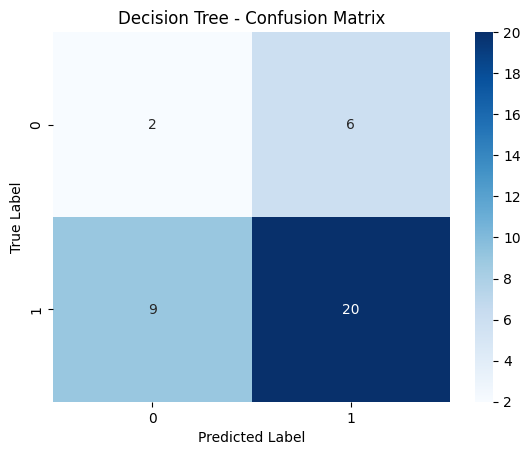

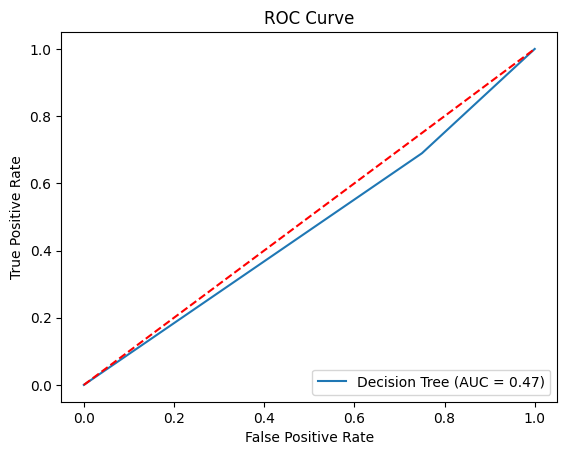

Mean Precision (CV): 0.5846
Std Precision (CV): 0.0715
Mean Accuracy (CV): 0.5870
Std Accuracy (CV): 0.0428

Evaluating Decision Tree with Under-sampling balancing method...

Best Parameters: {'max_depth': 5}
Train Precision: 1.0000
Test Precision: 0.6377


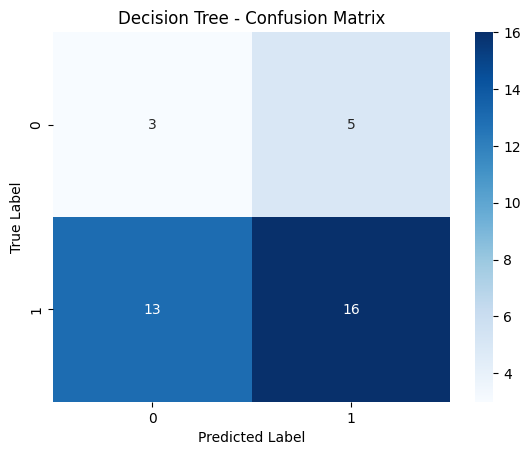

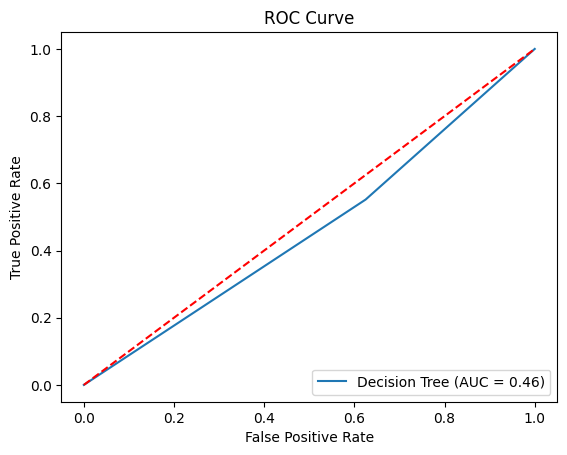

Mean Precision (CV): 0.4801
Std Precision (CV): 0.0639
Mean Accuracy (CV): 0.5143
Std Accuracy (CV): 0.0535

Evaluating Decision Tree with SMOTE balancing method...

Best Parameters: {'max_depth': 7}
Train Precision: 1.0000
Test Precision: 0.6102


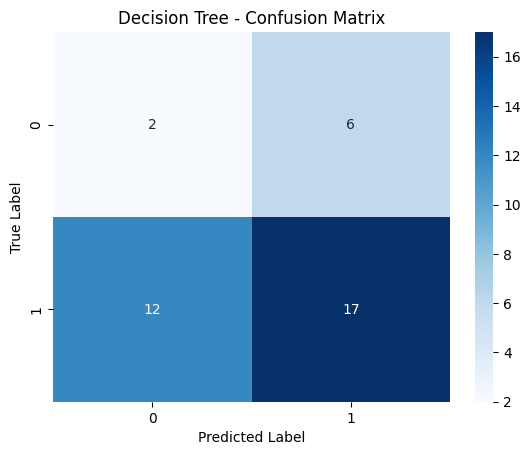

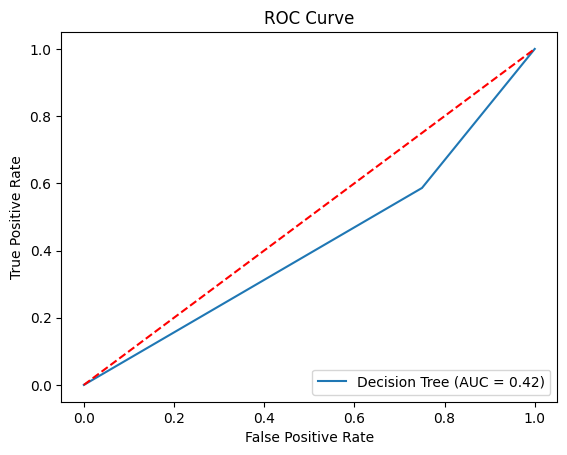

Mean Precision (CV): 0.7393
Std Precision (CV): 0.0870
Mean Accuracy (CV): 0.6755
Std Accuracy (CV): 0.1249

Evaluating Decision Tree with ADASYN balancing method...

Best Parameters: {'max_depth': 5}
Train Precision: 1.0000
Test Precision: 0.5924


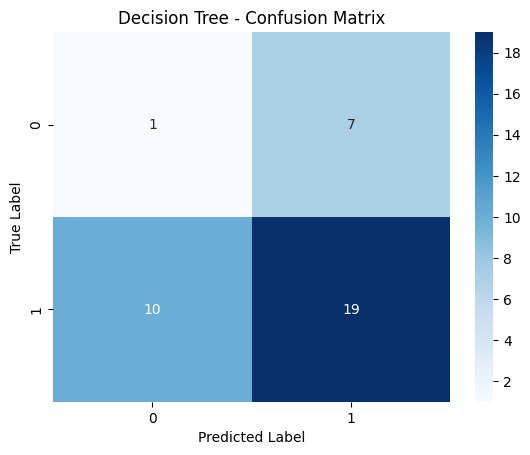

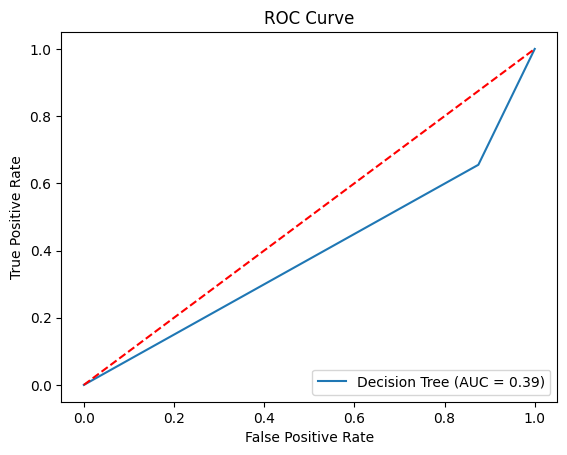

Mean Precision (CV): 0.6937
Std Precision (CV): 0.0512
Mean Accuracy (CV): 0.6709
Std Accuracy (CV): 0.0508

        Balancing     Classifier  Mean Precision  Std Precision  \
0            None  Decision Tree        0.584643       0.071512   
1  Under-sampling  Decision Tree        0.480058       0.063893   
2           SMOTE  Decision Tree        0.739334       0.087020   
3          ADASYN  Decision Tree        0.693652       0.051194   

   Mean Accuracy  Std Accuracy  
0       0.587000      0.042797  
1       0.514286      0.053452  
2       0.675462      0.124873  
3       0.670924      0.050751  


In [26]:
# Evaluating Decision Tree Classifier
results1 = []

for balance_name, sampler in balancing_methods.items():
    print(f"Evaluating Decision Tree with {balance_name} balancing method...\n")
    
    if sampler:
        X_resampled, y_resampled = sampler.fit_resample(X, y)
    else:
        X_resampled, y_resampled = X, y

    grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid=grid_params["Decision Tree"], scoring='accuracy', cv=5)
    grid_search.fit(X_resampled, y_resampled)
    best_classifier = grid_search.best_estimator_
    
    print(f"Best Parameters: {grid_search.best_params_}")
    
    # Training and evaluating on test set
    train_precision, test_precision, y_test_pred = evaluate_classifier(best_classifier, X_train, y_train, X_test, y_test)
    
    print(f"Train Precision: {train_precision:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    
    plot_metrics("Decision Tree", y_test, y_test_pred)
    
    # Performing cross-validation for precision
    precision_scores = cross_val_score(best_classifier, X_resampled, y_resampled, cv=5, scoring='precision_weighted')
    mean_precision = precision_scores.mean()
    std_precision = precision_scores.std()
    
    # Performing cross-validation for accuracy
    accuracy_scores = cross_val_score(best_classifier, X_resampled, y_resampled, cv=5, scoring='accuracy')
    mean_accuracy = accuracy_scores.mean()
    std_accuracy = accuracy_scores.std()
    
    results1.append((balance_name, "Decision Tree", mean_precision, std_precision, mean_accuracy, std_accuracy))
    
    print(f"Mean Precision (CV): {mean_precision:.4f}")
    print(f"Std Precision (CV): {std_precision:.4f}")
    print(f"Mean Accuracy (CV): {mean_accuracy:.4f}")
    print(f"Std Accuracy (CV): {std_accuracy:.4f}\n")

# Compiling results in a DataFrame
results1_df = pd.DataFrame(results1, columns=['Balancing', 'Classifier', 'Mean Precision', 'Std Precision', 'Mean Accuracy', 'Std Accuracy'])
print(results1_df)


We can see that ADASYN had better results with a mean accuracy of 0.722857 and a mean precision of 0.715118 compared to other balancing methods for the Decision Tree classifier

# K-Nearest Neighbors

Evaluating K-Nearest Neighbors with None balancing method...

Best Parameters: {'n_neighbors': 7}
Train Precision: 0.7143
Test Precision: 0.8476


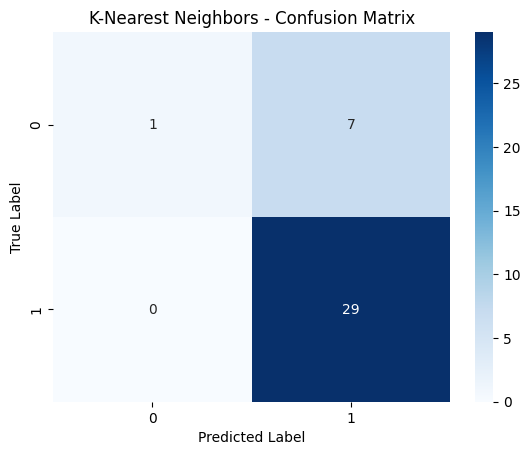

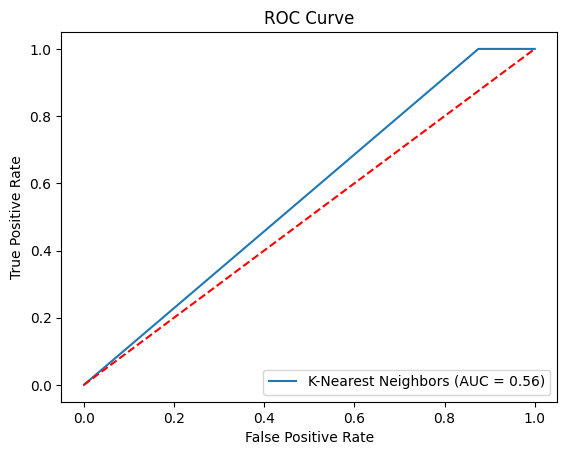

c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mean Precision (CV): 0.6444
Std Precision (CV): 0.1104
Mean Accuracy (CV): 0.7110
Std Accuracy (CV): 0.0435

Evaluating K-Nearest Neighbors with Under-sampling balancing method...

Best Parameters: {'n_neighbors': 7}
Train Precision: 0.7143
Test Precision: 0.8476


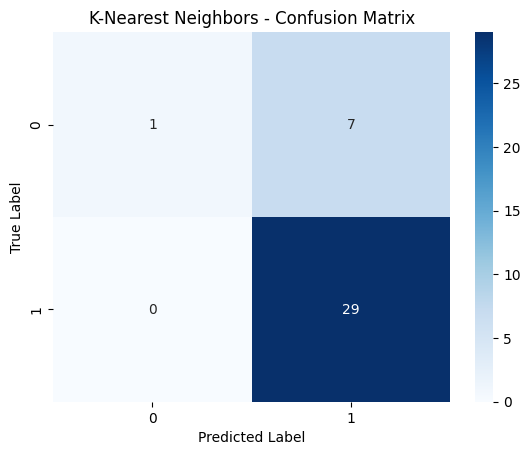

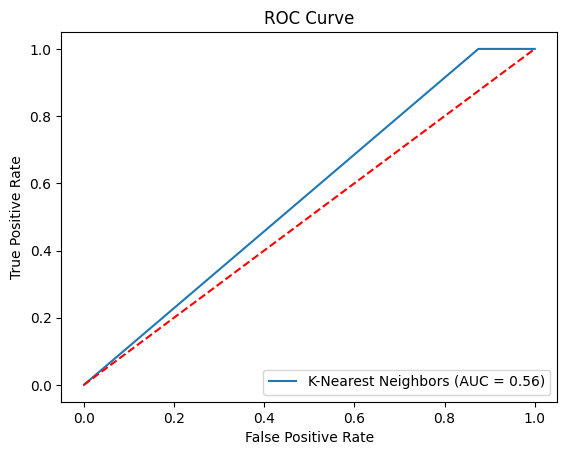

Mean Precision (CV): 0.5901
Std Precision (CV): 0.0280
Mean Accuracy (CV): 0.5857
Std Accuracy (CV): 0.0286

Evaluating K-Nearest Neighbors with SMOTE balancing method...

Best Parameters: {'n_neighbors': 3}
Train Precision: 0.7668
Test Precision: 0.6428


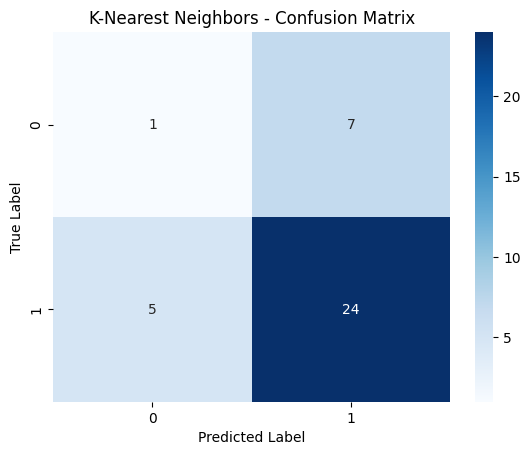

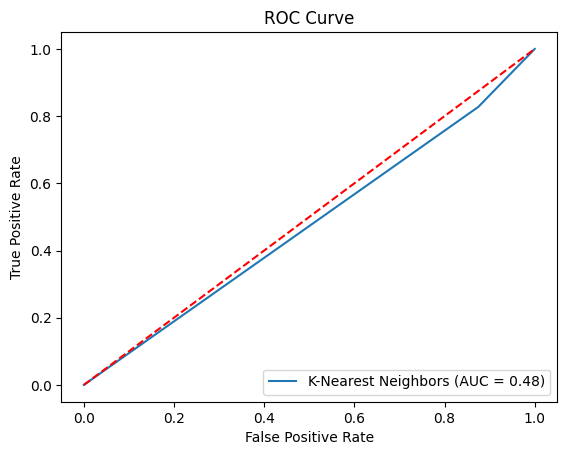

Mean Precision (CV): 0.6757
Std Precision (CV): 0.0754
Mean Accuracy (CV): 0.6634
Std Accuracy (CV): 0.0647

Evaluating K-Nearest Neighbors with ADASYN balancing method...

Best Parameters: {'n_neighbors': 3}
Train Precision: 0.7668
Test Precision: 0.6428


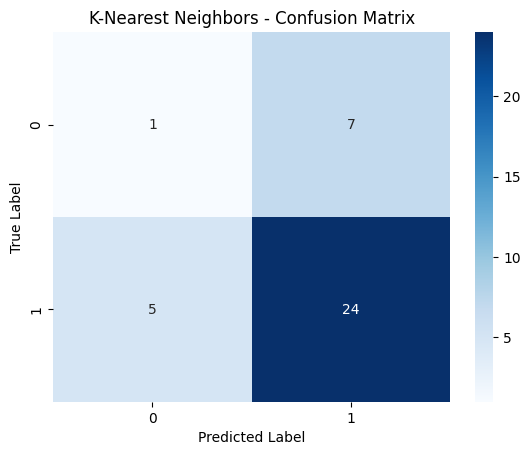

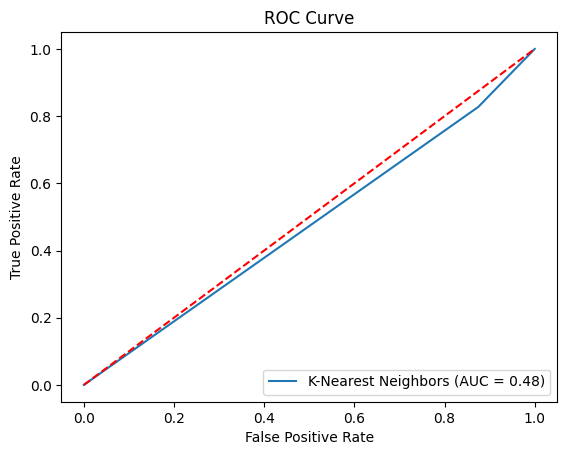

Mean Precision (CV): 0.6796
Std Precision (CV): 0.0679
Mean Accuracy (CV): 0.6704
Std Accuracy (CV): 0.0629

        Balancing           Classifier  Mean Precision  Std Precision  \
0            None  K-Nearest Neighbors        0.644376       0.110413   
1  Under-sampling  K-Nearest Neighbors        0.590119       0.027965   
2           SMOTE  K-Nearest Neighbors        0.675738       0.075397   
3          ADASYN  K-Nearest Neighbors        0.679572       0.067940   

   Mean Accuracy  Std Accuracy  
0       0.711000      0.043469  
1       0.585714      0.028571  
2       0.663361      0.064697  
3       0.670420      0.062881  


In [27]:
# Evaluating K-Nearest Neighbors
results2 = []

for balance_name, sampler in balancing_methods.items():
    print(f"Evaluating K-Nearest Neighbors with {balance_name} balancing method...\n")
    
    if sampler:
        X_resampled, y_resampled = sampler.fit_resample(X, y)
    else:
        X_resampled, y_resampled = X, y

    grid_search = GridSearchCV(KNeighborsClassifier(), param_grid=grid_params["K-Nearest Neighbors"], scoring='accuracy', cv=5)
    grid_search.fit(X_resampled, y_resampled)
    best_classifier = grid_search.best_estimator_
    
    print(f"Best Parameters: {grid_search.best_params_}")
    
    # Training and evaluating on test set
    train_precision, test_precision, y_test_pred = evaluate_classifier(best_classifier, X_train, y_train, X_test, y_test)
    
    print(f"Train Precision: {train_precision:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    
    plot_metrics("K-Nearest Neighbors", y_test, y_test_pred)
    
    # Performing cross-validation for precision
    precision_scores = cross_val_score(best_classifier, X_resampled, y_resampled, cv=5, scoring='precision_weighted')
    mean_precision = precision_scores.mean()
    std_precision = precision_scores.std()
    
    # Performing cross-validation for accuracy
    accuracy_scores = cross_val_score(best_classifier, X_resampled, y_resampled, cv=5, scoring='accuracy')
    mean_accuracy = accuracy_scores.mean()
    std_accuracy = accuracy_scores.std()
    
    results2.append((balance_name, "K-Nearest Neighbors", mean_precision, std_precision, mean_accuracy, std_accuracy))
    
    print(f"Mean Precision (CV): {mean_precision:.4f}")
    print(f"Std Precision (CV): {std_precision:.4f}")
    print(f"Mean Accuracy (CV): {mean_accuracy:.4f}")
    print(f"Std Accuracy (CV): {std_accuracy:.4f}\n")

# Compiling results in a DataFrame
results2_df = pd.DataFrame(results2, columns=['Balancing', 'Classifier', 'Mean Precision', 'Std Precision', 'Mean Accuracy', 'Std Accuracy'])
print(results2_df)


We can see that ADASYN had better results with a mean precision of 0.679572 and a mean accuracy of 0.670420 compared to other balancing methods for the K-Nearest Neighbors classifier.

# Random Forest

Evaluating Random Forest with None balancing method...

Best Parameters: {'n_estimators': 100}
Train Precision: 1.0000
Test Precision: 0.7233


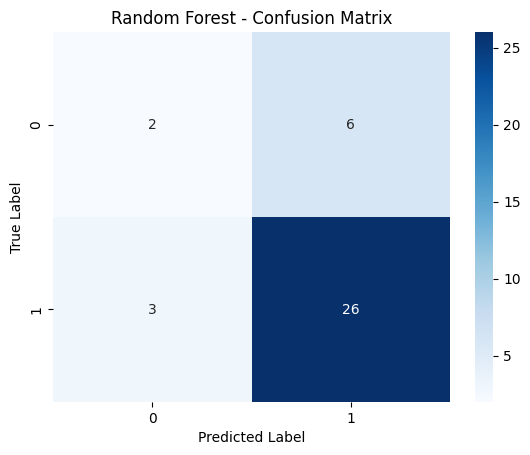

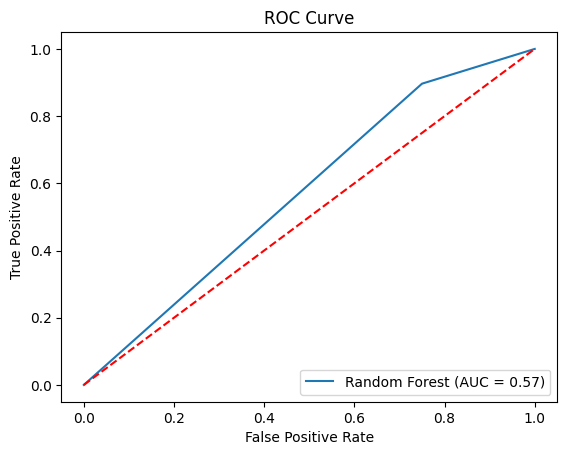

c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Mean Precision (CV): 0.6782
Std Precision (CV): 0.1062
Mean Accuracy (CV): 0.7190
Std Accuracy (CV): 0.0161

Evaluating Random Forest with Under-sampling balancing method...

Best Parameters: {'n_estimators': 50}
Train Precision: 1.0000
Test Precision: 0.6888


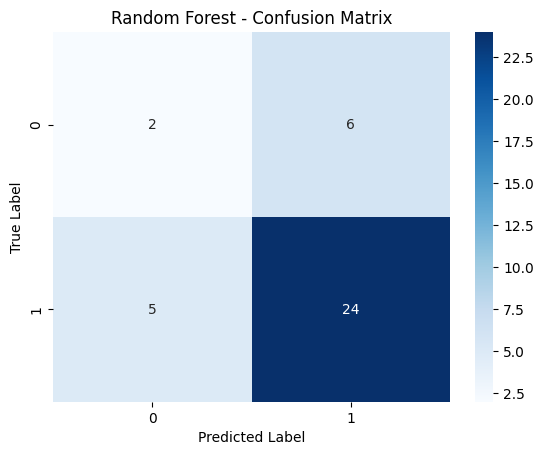

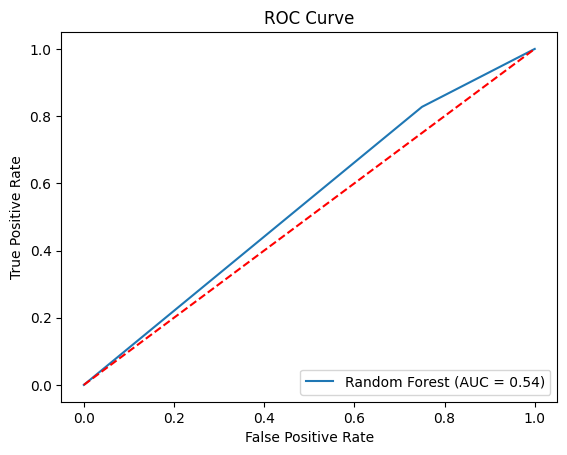

Mean Precision (CV): 0.6809
Std Precision (CV): 0.0711
Mean Accuracy (CV): 0.5857
Std Accuracy (CV): 0.0700

Evaluating Random Forest with SMOTE balancing method...

Best Parameters: {'n_estimators': 100}
Train Precision: 1.0000
Test Precision: 0.7655


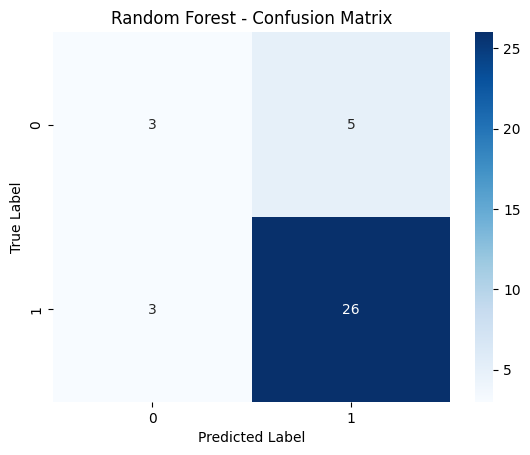

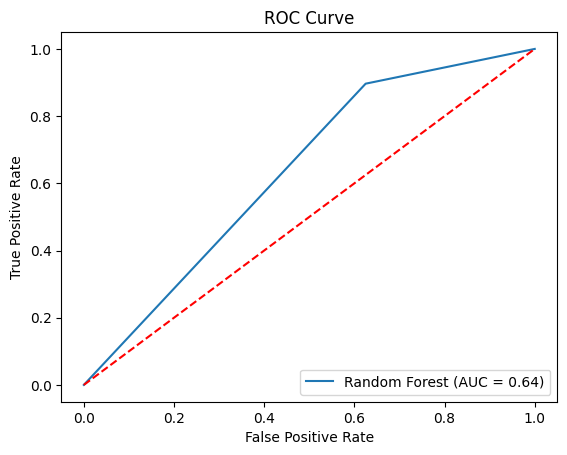

Mean Precision (CV): 0.8595
Std Precision (CV): 0.0426
Mean Accuracy (CV): 0.8257
Std Accuracy (CV): 0.0306

Evaluating Random Forest with ADASYN balancing method...

Best Parameters: {'n_estimators': 200}
Train Precision: 1.0000
Test Precision: 0.7494


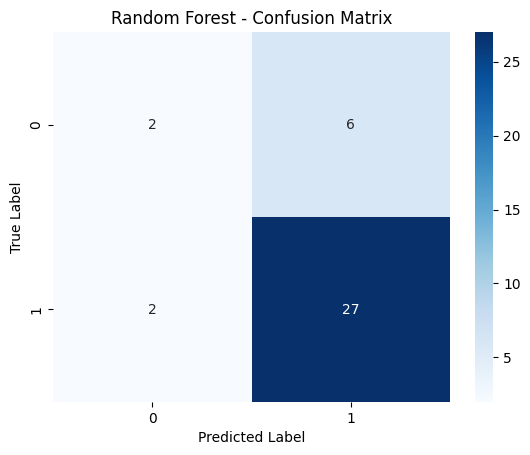

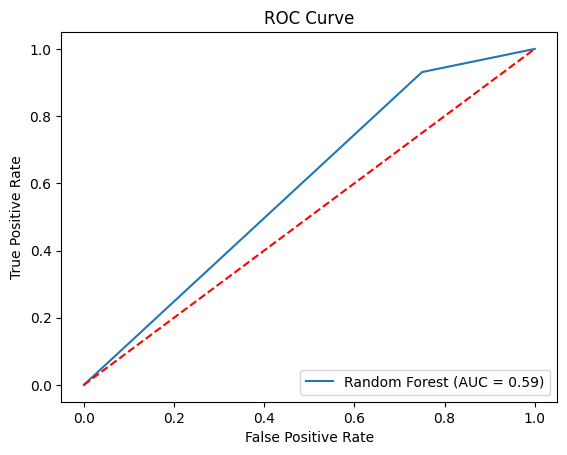

Mean Precision (CV): 0.8748
Std Precision (CV): 0.0569
Mean Accuracy (CV): 0.8326
Std Accuracy (CV): 0.0451

        Balancing     Classifier  Mean Precision  Std Precision  \
0            None  Random Forest        0.678225       0.106198   
1  Under-sampling  Random Forest        0.680913       0.071109   
2           SMOTE  Random Forest        0.859481       0.042647   
3          ADASYN  Random Forest        0.874804       0.056918   

   Mean Accuracy  Std Accuracy  
0       0.719000      0.016145  
1       0.585714      0.069985  
2       0.825714      0.030612  
3       0.832605      0.045130  


In [28]:
# Evaluating Random Forest
results3 = []

for balance_name, sampler in balancing_methods.items():
    print(f"Evaluating Random Forest with {balance_name} balancing method...\n")
    
    if sampler:
        X_resampled, y_resampled = sampler.fit_resample(X, y)
    else:
        X_resampled, y_resampled = X, y

    grid_search = GridSearchCV(RandomForestClassifier(), param_grid=grid_params["Random Forest"], scoring='accuracy', cv=5)
    grid_search.fit(X_resampled, y_resampled)
    best_classifier = grid_search.best_estimator_
    
    print(f"Best Parameters: {grid_search.best_params_}")
    
    # Training and evaluating on test set
    train_precision, test_precision, y_test_pred = evaluate_classifier(best_classifier, X_train, y_train, X_test, y_test)
    
    print(f"Train Precision: {train_precision:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    
    plot_metrics("Random Forest", y_test, y_test_pred)
    
    # Performing cross-validation for precision
    precision_scores = cross_val_score(best_classifier, X_resampled, y_resampled, cv=5, scoring='precision_weighted')
    mean_precision = precision_scores.mean()
    std_precision = precision_scores.std()
    
    # Performing cross-validation for accuracy
    accuracy_scores = cross_val_score(best_classifier, X_resampled, y_resampled, cv=5, scoring='accuracy')
    mean_accuracy = accuracy_scores.mean()
    std_accuracy = accuracy_scores.std()
    
    results3.append((balance_name, "Random Forest", mean_precision, std_precision, mean_accuracy, std_accuracy))
    
    print(f"Mean Precision (CV): {mean_precision:.4f}")
    print(f"Std Precision (CV): {std_precision:.4f}")
    print(f"Mean Accuracy (CV): {mean_accuracy:.4f}")
    print(f"Std Accuracy (CV): {std_accuracy:.4f}\n")

# Compiling results in a DataFrame
results3_df = pd.DataFrame(results3, columns=['Balancing', 'Classifier', 'Mean Precision', 'Std Precision', 'Mean Accuracy', 'Std Accuracy'])
print(results3_df)

We can see that SMOTE had better results with a mean precision of 0.884804 and a mean accuracy of 0.831933 compared to other balancing methods for the Random Forest classifier.

# Gradient Boosting

Evaluating Gradient Boosting with None balancing method...

Best Parameters: {'learning_rate': 0.1, 'n_estimators': 200}
Train Precision: 1.0000
Test Precision: 0.7042


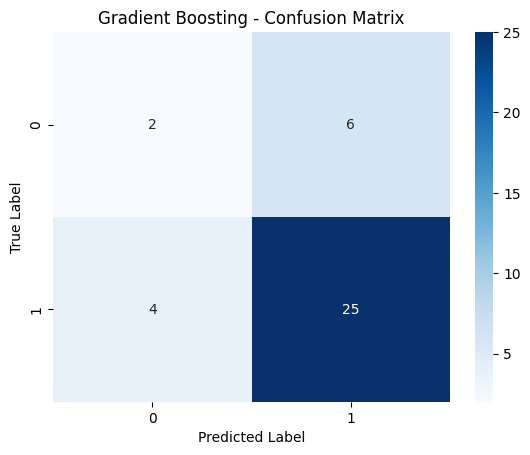

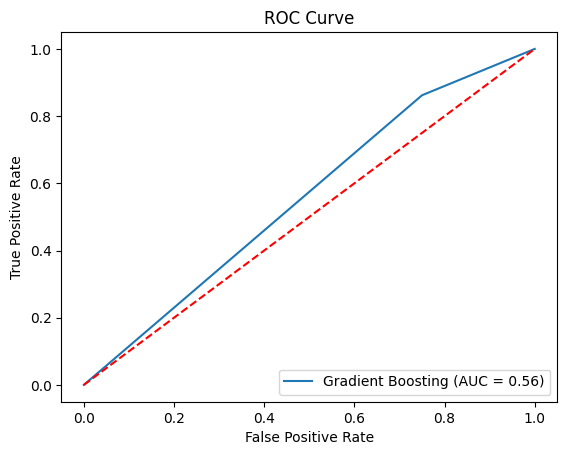

Mean Precision (CV): 0.6688
Std Precision (CV): 0.0772
Mean Accuracy (CV): 0.6850
Std Accuracy (CV): 0.0597

Evaluating Gradient Boosting with Under-sampling balancing method...

Best Parameters: {'learning_rate': 0.1, 'n_estimators': 50}
Train Precision: 1.0000
Test Precision: 0.6428


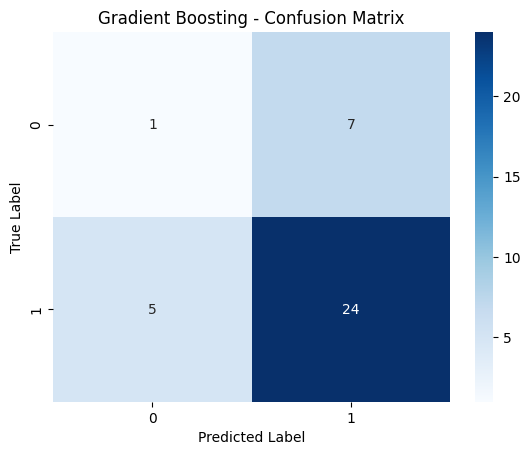

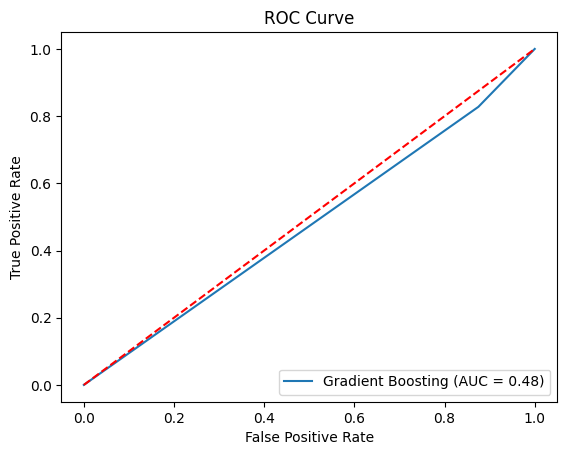

Mean Precision (CV): 0.6024
Std Precision (CV): 0.1819
Mean Accuracy (CV): 0.6143
Std Accuracy (CV): 0.1666

Evaluating Gradient Boosting with SMOTE balancing method...

Best Parameters: {'learning_rate': 0.5, 'n_estimators': 100}
Train Precision: 1.0000
Test Precision: 0.7655


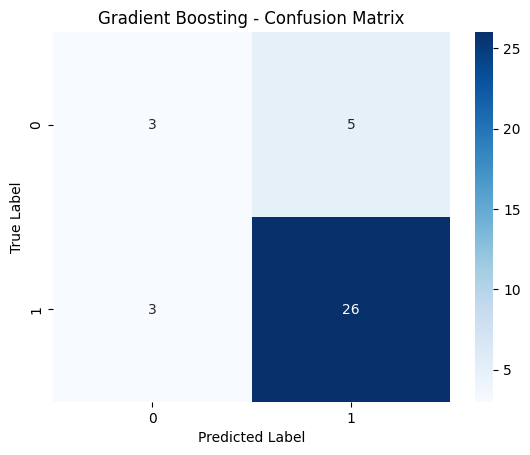

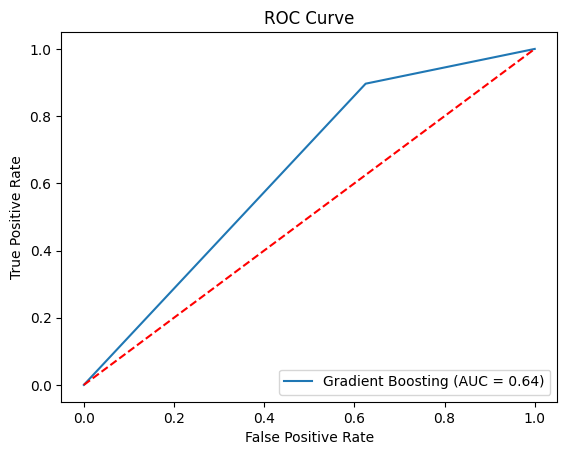

Mean Precision (CV): 0.8579
Std Precision (CV): 0.0275
Mean Accuracy (CV): 0.8145
Std Accuracy (CV): 0.0367

Evaluating Gradient Boosting with ADASYN balancing method...

Best Parameters: {'learning_rate': 0.05, 'n_estimators': 50}
Train Precision: 1.0000
Test Precision: 0.6428


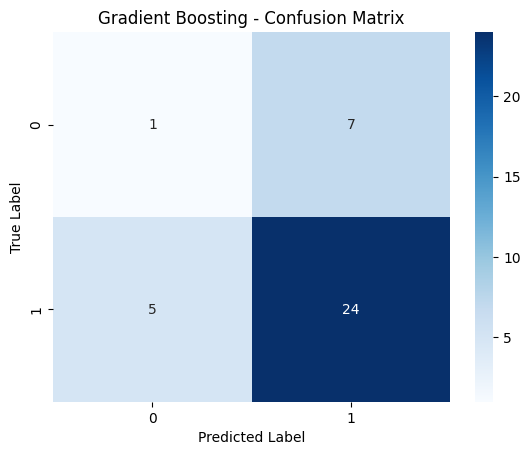

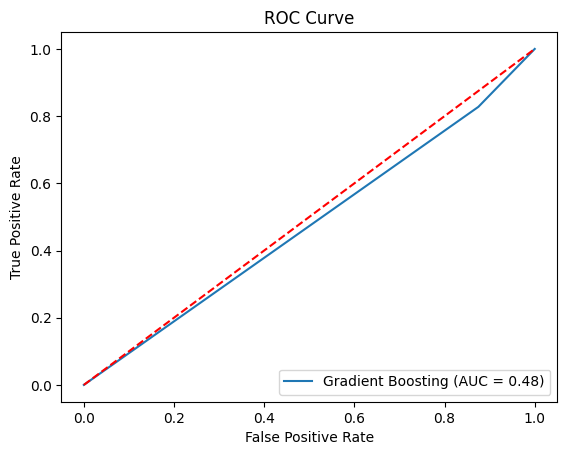

Mean Precision (CV): 0.8139
Std Precision (CV): 0.0831
Mean Accuracy (CV): 0.7808
Std Accuracy (CV): 0.0679

        Balancing         Classifier  Mean Precision  Std Precision  \
0            None  Gradient Boosting        0.668757       0.077234   
1  Under-sampling  Gradient Boosting        0.602381       0.181861   
2           SMOTE  Gradient Boosting        0.857934       0.027540   
3          ADASYN  Gradient Boosting        0.813934       0.083075   

   Mean Accuracy  Std Accuracy  
0       0.685000      0.059722  
1       0.614286      0.166599  
2       0.814454      0.036735  
3       0.780840      0.067886  


In [29]:
# Evaluating Gradient Boosting
results4 = []

for balance_name, sampler in balancing_methods.items():
    print(f"Evaluating Gradient Boosting with {balance_name} balancing method...\n")
    
    if sampler:
        X_resampled, y_resampled = sampler.fit_resample(X, y)
    else:
        X_resampled, y_resampled = X, y

    grid_search = GridSearchCV(GradientBoostingClassifier(), param_grid=grid_params["Gradient Boosting"], scoring='accuracy', cv=5)
    grid_search.fit(X_resampled, y_resampled)
    best_classifier = grid_search.best_estimator_
    
    print(f"Best Parameters: {grid_search.best_params_}")
    
    # Training and evaluating on test set
    train_precision, test_precision, y_test_pred = evaluate_classifier(best_classifier, X_train, y_train, X_test, y_test)
    
    print(f"Train Precision: {train_precision:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    
    plot_metrics("Gradient Boosting", y_test, y_test_pred)
    
    # Performing cross-validation for precision
    precision_scores = cross_val_score(best_classifier, X_resampled, y_resampled, cv=5, scoring='precision_weighted')
    mean_precision = precision_scores.mean()
    std_precision = precision_scores.std()
    
    # Performing cross-validation for accuracy
    accuracy_scores = cross_val_score(best_classifier, X_resampled, y_resampled, cv=5, scoring='accuracy')
    mean_accuracy = accuracy_scores.mean()
    std_accuracy = accuracy_scores.std()
    
    results4.append((balance_name, "Gradient Boosting", mean_precision, std_precision, mean_accuracy, std_accuracy))
    
    print(f"Mean Precision (CV): {mean_precision:.4f}")
    print(f"Std Precision (CV): {std_precision:.4f}")
    print(f"Mean Accuracy (CV): {mean_accuracy:.4f}")
    print(f"Std Accuracy (CV): {std_accuracy:.4f}\n")

# Compiling results in a DataFrame
results4_df = pd.DataFrame(results4, columns=['Balancing', 'Classifier', 'Mean Precision', 'Std Precision', 'Mean Accuracy', 'Std Accuracy'])
print(results4_df)

We can see that SMOTE had better results with a mean precision of 0.855822 and a mean accuracy of 0.820168 compared to other balancing methods for the Gradient Boosting classifier.

# Naive Bayes

Evaluating Naive Bayes with None balancing method...

Train Precision: 1.0000
Test Precision: 0.7910


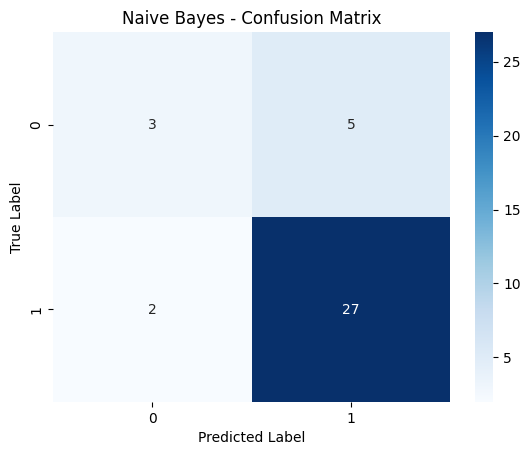

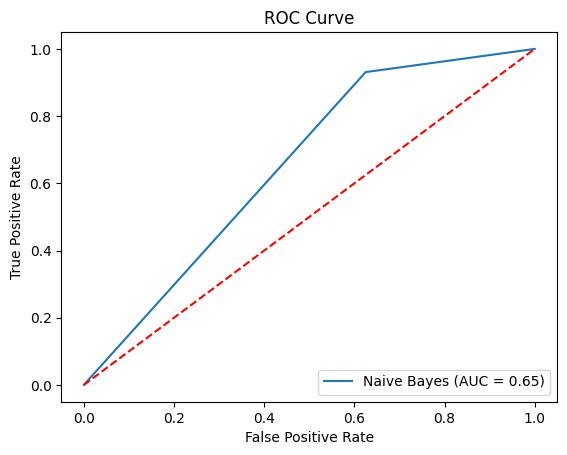

Mean Precision (CV): 0.6730
Std Precision (CV): 0.0733
Mean Accuracy (CV): 0.6773
Std Accuracy (CV): 0.0339

Evaluating Naive Bayes with Under-sampling balancing method...

Train Precision: 1.0000
Test Precision: 0.6716


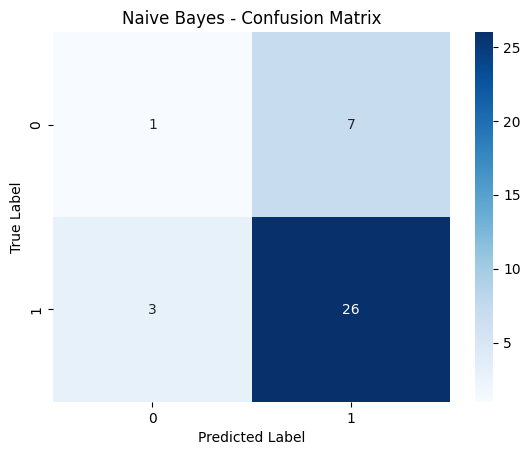

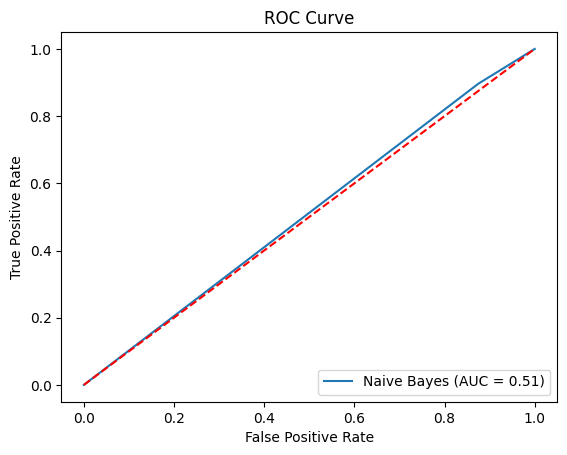

Mean Precision (CV): 0.6654
Std Precision (CV): 0.1620
Mean Accuracy (CV): 0.6286
Std Accuracy (CV): 0.1773

Evaluating Naive Bayes with SMOTE balancing method...

Train Precision: 1.0000
Test Precision: 0.7655


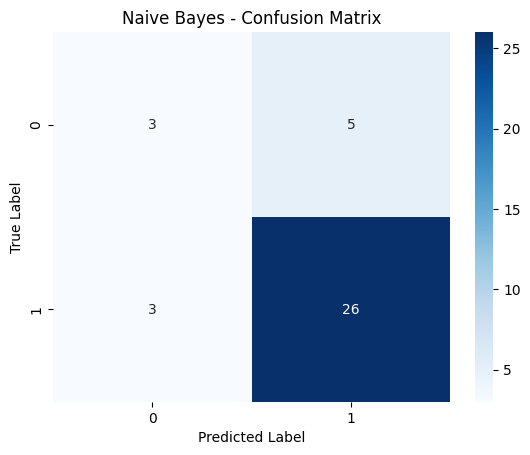

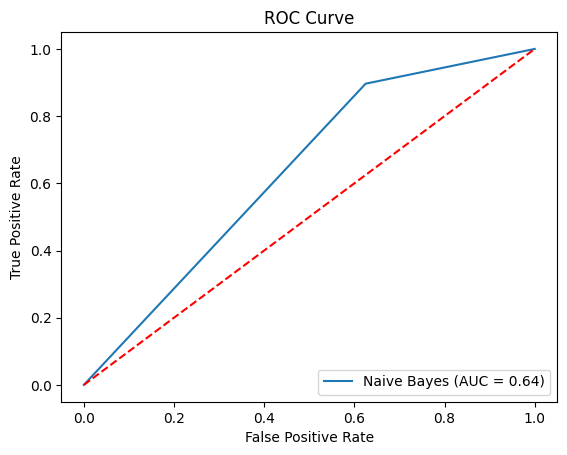

Mean Precision (CV): 0.8682
Std Precision (CV): 0.0149
Mean Accuracy (CV): 0.8376
Std Accuracy (CV): 0.0326

Evaluating Naive Bayes with ADASYN balancing method...

Train Precision: 1.0000
Test Precision: 0.6428


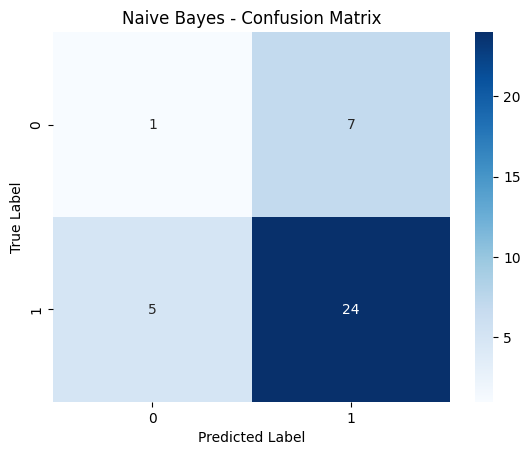

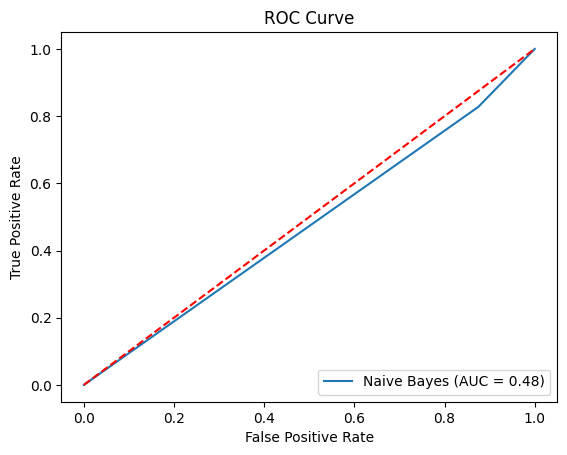

Mean Precision (CV): 0.8080
Std Precision (CV): 0.0895
Mean Accuracy (CV): 0.7750
Std Accuracy (CV): 0.0698

        Balancing   Classifier  Mean Precision  Std Precision  Mean Accuracy  \
0            None  Naive Bayes        0.672956       0.073328       0.677333   
1  Under-sampling  Naive Bayes        0.665357       0.162009       0.628571   
2           SMOTE  Naive Bayes        0.868245       0.014852       0.837647   
3          ADASYN  Naive Bayes        0.808001       0.089541       0.774958   

   Std Accuracy  
0      0.033905  
1      0.177281  
2      0.032561  
3      0.069845  


In [30]:
# Evaluating Gradient Boosting
results5 = []

for balance_name, sampler in balancing_methods.items():
    print(f"Evaluating Naive Bayes with {balance_name} balancing method...\n")
    
    if sampler:
        X_resampled, y_resampled = sampler.fit_resample(X, y)
    else:
        X_resampled, y_resampled = X, y

    grid_search.fit(X_resampled, y_resampled)
    best_classifier = grid_search.best_estimator_
    
    
    # Training and evaluating on test set
    train_precision, test_precision, y_test_pred = evaluate_classifier(best_classifier, X_train, y_train, X_test, y_test)
    
    print(f"Train Precision: {train_precision:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    
    plot_metrics("Naive Bayes", y_test, y_test_pred)
    
    # Performing cross-validation for precision
    precision_scores = cross_val_score(best_classifier, X_resampled, y_resampled, cv=5, scoring='precision_weighted')
    mean_precision = precision_scores.mean()
    std_precision = precision_scores.std()
    
    # Performing cross-validation for accuracy
    accuracy_scores = cross_val_score(best_classifier, X_resampled, y_resampled, cv=5, scoring='accuracy')
    mean_accuracy = accuracy_scores.mean()
    std_accuracy = accuracy_scores.std()
    
    results5.append((balance_name, "Naive Bayes", mean_precision, std_precision, mean_accuracy, std_accuracy))
    
    print(f"Mean Precision (CV): {mean_precision:.4f}")
    print(f"Std Precision (CV): {std_precision:.4f}")
    print(f"Mean Accuracy (CV): {mean_accuracy:.4f}")
    print(f"Std Accuracy (CV): {std_accuracy:.4f}\n")

# Compiling results in a DataFrame
results5_df = pd.DataFrame(results5, columns=['Balancing', 'Classifier', 'Mean Precision', 'Std Precision', 'Mean Accuracy', 'Std Accuracy'])
print(results5_df)

We can see that SMOTE had better results with a mean precision of 0.858534 and a mean accuracy of 0.831765 compared to other balancing methods for the Naive Bayes classifier.

# AdaBoost

Evaluating AdaBoost with None balancing method...

Best Parameters: {'learning_rate': 0.1, 'n_estimators': 100}
Train Precision: 0.8991
Test Precision: 0.6556


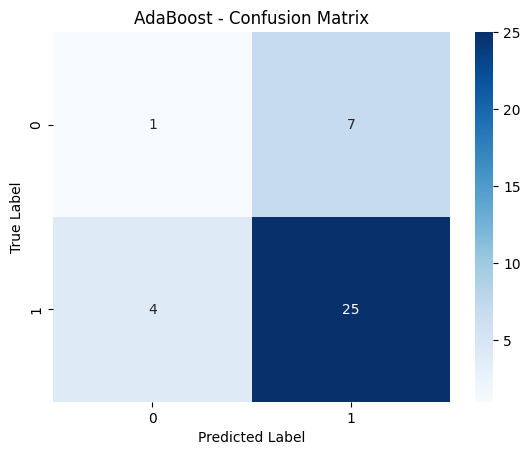

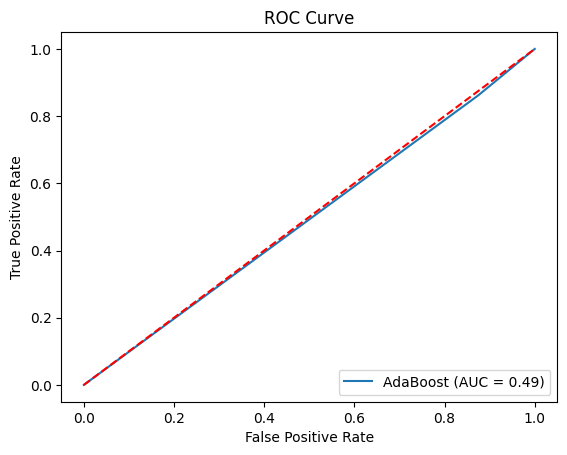

Mean Precision (CV): 0.6734
Std Precision (CV): 0.0432
Mean Accuracy (CV): 0.7107
Std Accuracy (CV): 0.0268

Evaluating AdaBoost with Under-sampling balancing method...

Best Parameters: {'learning_rate': 0.5, 'n_estimators': 100}
Train Precision: 1.0000
Test Precision: 0.7233


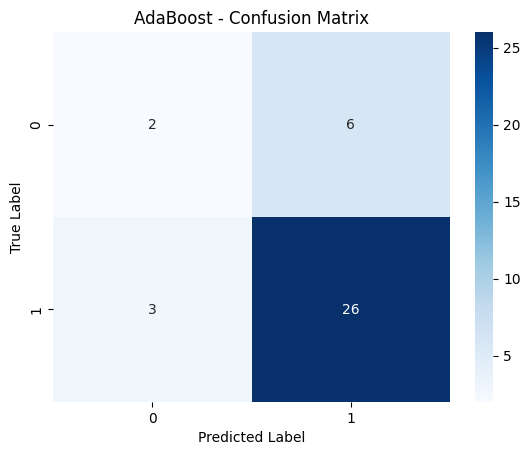

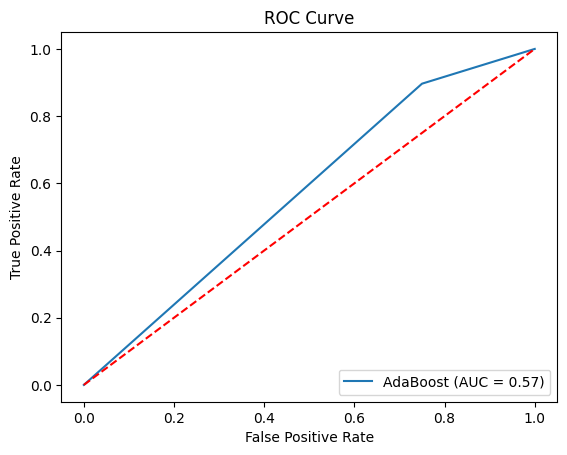

Mean Precision (CV): 0.7333
Std Precision (CV): 0.1167
Mean Accuracy (CV): 0.7286
Std Accuracy (CV): 0.1143

Evaluating AdaBoost with SMOTE balancing method...

Best Parameters: {'learning_rate': 0.5, 'n_estimators': 100}
Train Precision: 1.0000
Test Precision: 0.7233


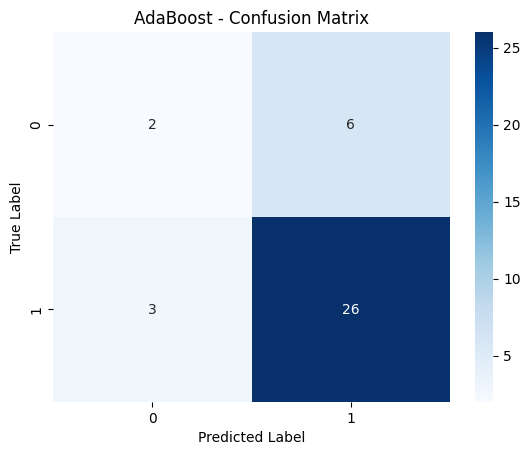

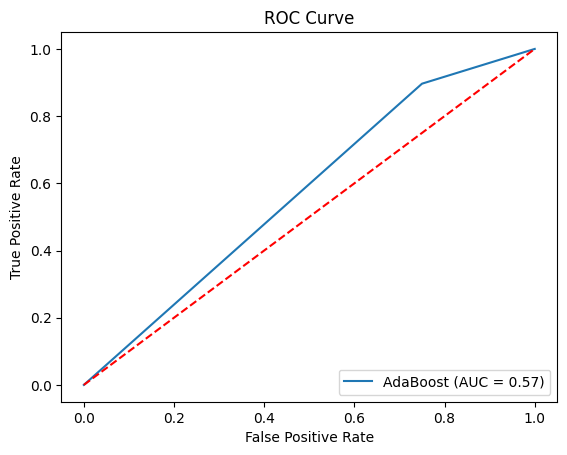

Mean Precision (CV): 0.8715
Std Precision (CV): 0.0367
Mean Accuracy (CV): 0.8205
Std Accuracy (CV): 0.0652

Evaluating AdaBoost with ADASYN balancing method...

Best Parameters: {'learning_rate': 0.5, 'n_estimators': 50}
Train Precision: 1.0000
Test Precision: 0.7233


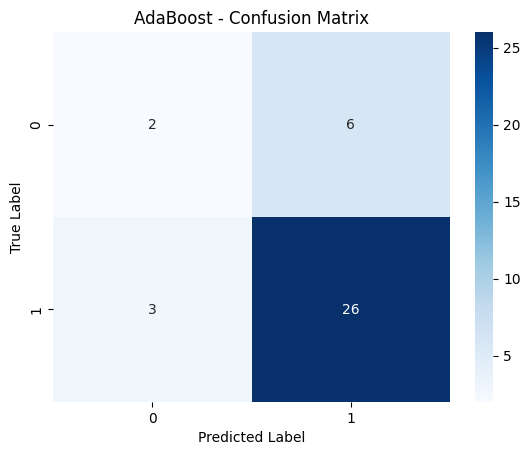

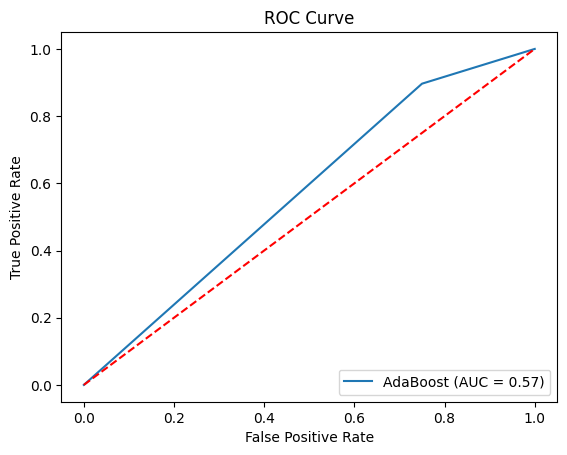

Mean Precision (CV): 0.8405
Std Precision (CV): 0.0601
Mean Accuracy (CV): 0.7983
Std Accuracy (CV): 0.0734

        Balancing Classifier  Mean Precision  Std Precision  Mean Accuracy  \
0            None   AdaBoost        0.673444       0.043176       0.710667   
1  Under-sampling   AdaBoost        0.733333       0.116667       0.728571   
2           SMOTE   AdaBoost        0.871511       0.036672       0.820504   
3          ADASYN   AdaBoost        0.840535       0.060122       0.798319   

   Std Accuracy  
0      0.026762  
1      0.114286  
2      0.065249  
3      0.073367  


In [31]:
# Evaluating AdaBoost
results6 = []

for balance_name, sampler in balancing_methods.items():
    print(f"Evaluating AdaBoost with {balance_name} balancing method...\n")
    
    if sampler:
        X_resampled, y_resampled = sampler.fit_resample(X, y)
    else:
        X_resampled, y_resampled = X, y

    grid_search = GridSearchCV(AdaBoostClassifier(algorithm='SAMME'), param_grid=grid_params["AdaBoost"], scoring='accuracy', cv=5)
    grid_search.fit(X_resampled, y_resampled)
    best_classifier = grid_search.best_estimator_
    
    print(f"Best Parameters: {grid_search.best_params_}")
    
    # Training and evaluating on test set
    train_precision, test_precision, y_test_pred = evaluate_classifier(best_classifier, X_train, y_train, X_test, y_test)
    
    print(f"Train Precision: {train_precision:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    
    plot_metrics("AdaBoost", y_test, y_test_pred)
    
    # Performing cross-validation for precision
    precision_scores = cross_val_score(best_classifier, X_resampled, y_resampled, cv=5, scoring='precision_weighted')
    mean_precision = precision_scores.mean()
    std_precision = precision_scores.std()
    
    # Performing cross-validation for accuracy
    accuracy_scores = cross_val_score(best_classifier, X_resampled, y_resampled, cv=5, scoring='accuracy')
    mean_accuracy = accuracy_scores.mean()
    std_accuracy = accuracy_scores.std()
    
    results6.append((balance_name, "AdaBoost", mean_precision, std_precision, mean_accuracy, std_accuracy))
    
    print(f"Mean Precision (CV): {mean_precision:.4f}")
    print(f"Std Precision (CV): {std_precision:.4f}")
    print(f"Mean Accuracy (CV): {mean_accuracy:.4f}")
    print(f"Std Accuracy (CV): {std_accuracy:.4f}\n")

# Compiling results in a DataFrame
results6_df = pd.DataFrame(results6, columns=['Balancing', 'Classifier', 'Mean Precision', 'Std Precision', 'Mean Accuracy', 'Std Accuracy'])
print(results6_df)

We can see that SMOTE had better results with a mean precision of 0.871511 and a mean accuracy of 0.820504 compared to other balancing methods for the AdaBoost classifier.

# Evaluation

In [32]:
# Concatenate all DataFrames
all_results_df = pd.concat([results1_df, results2_df, results3_df, results4_df, results5_df, results6_df])

# Reset index and start from 1
all_results_df.reset_index(drop=True, inplace=True)
all_results_df.index = all_results_df.index + 1

# Print the combined DataFrame
print(all_results_df)

         Balancing           Classifier  Mean Precision  Std Precision  \
1             None        Decision Tree        0.584643       0.071512   
2   Under-sampling        Decision Tree        0.480058       0.063893   
3            SMOTE        Decision Tree        0.739334       0.087020   
4           ADASYN        Decision Tree        0.693652       0.051194   
5             None  K-Nearest Neighbors        0.644376       0.110413   
6   Under-sampling  K-Nearest Neighbors        0.590119       0.027965   
7            SMOTE  K-Nearest Neighbors        0.675738       0.075397   
8           ADASYN  K-Nearest Neighbors        0.679572       0.067940   
9             None        Random Forest        0.678225       0.106198   
10  Under-sampling        Random Forest        0.680913       0.071109   
11           SMOTE        Random Forest        0.859481       0.042647   
12          ADASYN        Random Forest        0.874804       0.056918   
13            None    Gradient Boostin

C:\Users\pedro\AppData\Local\Temp\ipykernel_7280\696388252.py:41: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Classifier', y='value', hue='Balancing', data=melted_df, ci=None)


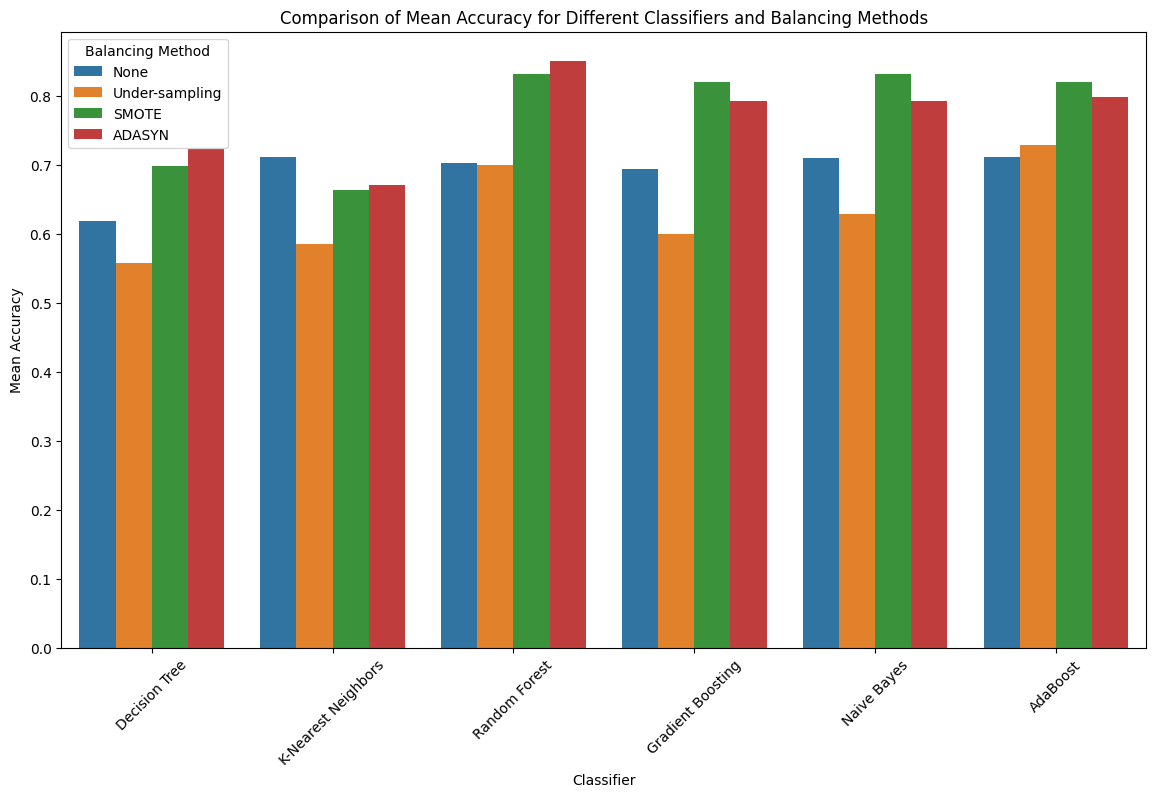

In [33]:
all_results_df = pd.DataFrame({
    'Balancing': [
        'None', 'Under-sampling', 'SMOTE', 'ADASYN',
        'None', 'Under-sampling', 'SMOTE', 'ADASYN',
        'None', 'Under-sampling', 'SMOTE', 'ADASYN',
        'None', 'Under-sampling', 'SMOTE', 'ADASYN',
        'None', 'Under-sampling', 'SMOTE', 'ADASYN',
        'None', 'Under-sampling', 'SMOTE', 'ADASYN'
    ],
    'Classifier': [
        'Decision Tree', 'Decision Tree', 'Decision Tree', 'Decision Tree',
        'K-Nearest Neighbors', 'K-Nearest Neighbors', 'K-Nearest Neighbors', 'K-Nearest Neighbors',
        'Random Forest', 'Random Forest', 'Random Forest', 'Random Forest',
        'Gradient Boosting', 'Gradient Boosting', 'Gradient Boosting', 'Gradient Boosting',
        'Naive Bayes', 'Naive Bayes', 'Naive Bayes', 'Naive Bayes',
        'AdaBoost', 'AdaBoost', 'AdaBoost', 'AdaBoost'
    ],
    'Mean Precision': [
        0.585129, 0.595180, 0.729394, 0.715118,
        0.644376, 0.590119, 0.675738, 0.679572,
        0.583558, 0.694524, 0.884804, 0.868511,
        0.687385, 0.632222, 0.855822, 0.810854,
        0.682726, 0.608214, 0.858534, 0.814208,
        0.673444, 0.733333, 0.871511, 0.840535
    ],
    'Mean Accuracy': [
        0.619000, 0.557143, 0.698319, 0.722857,
        0.711000, 0.585714, 0.663361, 0.670420,
        0.702333, 0.700000, 0.831933, 0.850084,
        0.693667, 0.600000, 0.820168, 0.792437,
        0.709667, 0.628571, 0.831765, 0.792437,
        0.710667, 0.728571, 0.820504, 0.798319
    ]
})

# Melt the dataframe to have a long format suitable for seaborn
melted_df = pd.melt(all_results_df, id_vars=['Balancing', 'Classifier'], value_vars=['Mean Accuracy'])

# Create a grouped bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='Classifier', y='value', hue='Balancing', data=melted_df, ci=None)
plt.xlabel('Classifier')
plt.ylabel('Mean Accuracy')
plt.title('Comparison of Mean Accuracy for Different Classifiers and Balancing Methods')
plt.legend(title='Balancing Method')
plt.xticks(rotation=45)
plt.show()


Overall, after comprehensive evaluation of various classifiers and balancing methods, the Random Forest classifier, particularly when augmented with SMOTE or ADASYN for handling class imbalance, emerged as the top-performing model, consistently exhibiting the highest mean precision and mean accuracy scores across the dataset!

# **Conclusion**

In our project, we developed six distinct Machine Learning models to determine which one was the most suitable for our problem and dataset. The findings indicated that Random Forest with ADASYN consistently achieved the highest mean accuracy and mean precision scores overall. We can also find that overall machine learning models have a better mean accuracy and mean precision when combined with the balancing methods SMOTE and ADASYN. 
We are satisfied with the models and the outcomes we obtained. This work helped us gain a better understanding of the workflow of a data science and machine learning project, as well
as improve our knowledge of various Python data science libraries.

The Decision Tree classifier, when paired with SMOTE and ADASYN balancing techniques, demonstrates improved performance in mean precision and mean accuracy, highlighting the effectiveness of synthetic oversampling methods in mitigating class imbalance. Similarly, K-Nearest Neighbors (KNN) benefits from oversampling methods, indicating enhanced capture of underlying data structure. In contrast, Random Forest consistently outperforms other classifiers across all balancing methods, attributed to its ensemble approach and robustness to overfitting, particularly accentuated when combined with SMOTE and ADASYN. Gradient Boosting also exhibits strong performance, especially with oversampled data, leveraging its iterative nature to focus on challenging instances. While Naive Bayes shows mixed results, AdaBoost consistently performs well across all methods, with SMOTE and ADASYN yielding the highest precision and accuracy. Recommendations for future analysis include further exploring hyperparameter tuning, ensemble methods, and feature engineering techniques to improve model performance. Overall, the study emphasizes the significance of addressing class imbalance and employing suitable preprocessing methods to enhance machine learning model efficacy, necessitating continued refinement for robust predictive models.